# Chapter 4 — Causal Intelligence in Practice  
## From Research Question to Credible Causal Analysis

**Course:** Causal Intelligence  
**Instructor:** Prof. Reza Arghandeh, Western Norway University of Applied Sciences, Norway  

---

## Main purpose

This chapter provides a practical workflow for applying causal inference in scientific research when the causal graph is uncertain, domain knowledge is incomplete, and the dataset was not designed as a randomized experiment.

Chapters 1–3 introduced the conceptual and methodological foundations of causal intelligence: association, intervention, counterfactual reasoning, causal graphs, causal discovery, adjustment, treatment-effect estimation, heterogeneous effects, and causal machine learning. This chapter shows how these ideas can be combined into a disciplined research workflow.

The chapter is designed as a bridge between causal methods and students' own research problems. It shows how to move from:

**dataset → research question → time order → variable audit → candidate graph → discovery-style diagnostics → identification strategy → estimation method → robustness checks → responsible causal interpretation**

The central message is:

> Causal inference is not only a collection of algorithms. It is a disciplined research workflow that combines data, assumptions, domain knowledge, diagnostics, estimation, robustness checks, and honest reporting.


## Chapter structure

1. Why causal analysis is difficult in real research  
2. Running example: a hidden-DAG healthcare study  
3. Causal intelligence workflow: from dataset to credible causal claim  
   3.1 Step 1: formulate the causal question  
   3.2 Step 2: define unit, treatment, outcome, and time order  
   3.3 Step 3: audit the variables  
   3.4 Step 4: build candidate causal graphs  
   3.5 Step 5: use causal discovery as a support tool  
   3.6 Step 6: decide whether the effect is identifiable  
   3.7 Step 7: choose and implement estimation methods  
   3.8 Step 8: validate and stress-test the analysis  
   3.9 Step 9: report causal conclusions responsibly  
4. Reveal the hidden data-generating process  
5. Chapter summary
6. References and Further Reading

</br>

---
## 1. Why causal analysis is difficult in real research

In previous chapters, we studied causal graphs, adjustment, causal discovery, and causal machine learning. Those tools are powerful, but real research projects are often messier than textbook examples.

In practice:

- the true causal graph is rarely known;
- domain knowledge is incomplete;
- variables may be missing, noisy, latent, or measured at the wrong time;
- treatment or exposure is usually not randomized;
- the dataset may contain only selected units;
- causal discovery may suggest candidate edges, but it cannot prove causality by itself;
- different estimators may give different answers.

This chapter focuses on the practical design of a credible causal analysis.

| Task | Main question | Main risk |
|---|---|---|
| Prediction | Can we predict $Y$ from observed features? | High accuracy may rely on spurious associations |
| Causal effect estimation | What would happen to $Y$ if we intervened on $T$? | Confounding, wrong adjustment, poor overlap |
| Causal discovery | What graph structures are consistent with the data? | Algorithmic output may be mistaken for causal truth |
| Responsible causal reporting | What can we claim under our assumptions? | Overstating what observational data can support |

In applied research, causal intelligence means knowing which task is justified by the available data and assumptions.


---
### Notebook setup: libraries and visual style

The notebook uses standard Python libraries so that it can run in Google Colab without heavy installation requirements.

The examples use a consistent visual style across the chapter:

- light blue: background or pre-treatment variables;
- light orange: confounders, risk indicators, or important causal variables;
- light green: treatment and outcome;
- light red: post-treatment, selection, or potentially problematic variables.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
})

COLORS = {
    "navy": "#1f4e79",
    "orange": "#f28e2b",
    "green": "#59a14f",
    "red": "#e15759",
    "gray": "#7f7f7f",
    "light_blue": "#d8e8f5",
    "light_orange": "#fde6c8",
    "light_green": "#d9ead3",
    "light_red": "#f4cccc",
}

def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    return ax

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def display_df(df, decimals=3):
    display(df.round(decimals))

def draw_dag(edges, pos=None, title="Causal graph", node_colors=None, figsize=(8, 5), arrows=True):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    node_colors = node_colors or {node: COLORS["light_blue"] for node in G.nodes()}
    colors = [node_colors.get(node, COLORS["light_blue"]) for node in G.nodes()]
    plt.figure(figsize=figsize)
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=3000,
        node_color=colors,
        edgecolors=COLORS["navy"],
        arrows=arrows,
        arrowsize=18,
        font_size=9,
        font_weight="bold",
        width=1.8,
    )
    plt.title(title)
    plt.axis("off")
    plt.show()
    return G

def residualize(y, X):
    y = np.asarray(y).reshape(-1)
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    return y - model.predict(X)

def partial_corr(df, x, y, controls=None):
    controls = controls or []
    if len(controls) == 0:
        return df[[x, y]].corr().iloc[0, 1]
    rx = residualize(df[x], df[controls])
    ry = residualize(df[y], df[controls])
    return np.corrcoef(rx, ry)[0, 1]


---
## 2. Running example: a hidden-DAG healthcare study

We use one simulated healthcare dataset throughout this chapter. The setting is a hospital that wants to evaluate whether a treatment improves patient recovery.

The important teaching feature is that we initially treat the data as if the true causal graph is unknown. This is closer to real research practice. Many PhD projects begin with a dataset, a scientific question, and partial domain knowledge, but not a complete causal structure.

The running workflow is:

**observed data → causal question → variable audit → candidate graph → discovery-style diagnostics → identification decision → estimation → robustness checks → responsible interpretation**

At the end of the chapter, we reveal the hidden data-generating process. This lets us compare our workflow with the true simulation, but only after we have practiced the reasoning process.

### Observed variables

| Variable | Meaning | Initial interpretation |
|---|---|---|
| `Age` | Patient age | Background pre-treatment variable |
| `Socioeconomic` | Socioeconomic status proxy | Background pre-treatment variable |
| `Access` | Access to healthcare resources | Context and possible selection factor |
| `Severity` | Baseline disease severity before treatment | Possible confounder |
| `Biomarker` | Clinical biomarker before treatment | Possible risk indicator and proxy |
| `HospitalPolicy` | Local tendency to assign treatment | Institutional treatment-assignment factor |
| `Treatment` | Whether the patient receives treatment | Treatment/intervention |
| `Inflammation` | Biological response after treatment | Possible mediator |
| `SpecialistClinic` | Whether the patient appears in a specialist clinic dataset | Possible selection/collider variable |
| `RecoveryScore` | Continuous recovery score; higher is better | Main outcome |
| `Recovery` | Binary recovery indicator | Auxiliary outcome |

The main research question is:

> Would assigning treatment improve the average recovery score in this patient population?

The target is the Average Treatment Effect:

$$ATE = E[RecoveryScore(1) - RecoveryScore(0)]$$

or:

$$ATE = E[RecoveryScore \mid do(Treatment=1)] - E[RecoveryScore \mid do(Treatment=0)]$$

The code below creates the dataset. The observed table `health` is what the analyst can use. The table `hidden_truth` contains latent variables and potential outcomes; we keep it hidden until Section 4.


In [2]:
def simulate_hidden_healthcare_data(n=3500, seed=42):
    rng = np.random.default_rng(seed)

    age = rng.normal(55, 12, n)
    age_std = (age - 55) / 12
    socioeconomic = rng.normal(0, 1, n)
    access = rng.normal(0, 1, n)

    # Latent background risk, not observed by the analyst
    latent_frailty = rng.normal(0, 1, n)

    # Pre-treatment clinical state
    severity = (
        0.45 * age_std
        - 0.55 * socioeconomic
        + 0.40 * latent_frailty
        + rng.normal(0, 1.0, n)
    )

    biomarker = (
        0.85 * severity
        + 0.20 * age_std
        + 0.35 * latent_frailty
        + rng.normal(0, 0.8, n)
    )

    # Institutional treatment tendency
    hospital_policy = rng.normal(0, 1, n)

    # Observational treatment assignment
    p_treatment = sigmoid(
        -0.30
        + 0.95 * severity
        + 0.45 * biomarker
        - 0.15 * socioeconomic
        + 0.45 * hospital_policy
    )
    treatment = rng.binomial(1, p_treatment, n)

    # Heterogeneous treatment effect
    true_treatment_effect = (
        4.0
        + 2.8 * sigmoid(severity)
        + 1.2 * (biomarker > np.median(biomarker)).astype(float)
        - 0.5 * age_std
    )
    true_treatment_effect = np.clip(true_treatment_effect, 1.0, 9.5)

    # Potential outcomes for a continuous recovery score
    baseline_noise = rng.normal(0, 4.0, n)
    y0 = (
        72
        - 7.0 * severity
        - 1.3 * age_std
        + 2.0 * socioeconomic
        - 1.2 * latent_frailty
        + baseline_noise
    )
    y1 = y0 + true_treatment_effect
    recovery_score = np.where(treatment == 1, y1, y0)

    # Post-treatment mediator-like variable
    inflammation = (
        1.05 * severity
        - 0.65 * treatment
        + 0.25 * latent_frailty
        + rng.normal(0, 0.9, n)
    )

    # Binary recovery indicator
    p_recovery = sigmoid((recovery_score - 70) / 8)
    recovery = rng.binomial(1, p_recovery, n)

    # Selection/collider variable
    p_specialist = sigmoid(-0.30 + 1.10 * severity + 1.05 * access + 0.20 * hospital_policy)
    specialist_clinic = rng.binomial(1, p_specialist, n)

    observed = pd.DataFrame({
        "Age": age,
        "Socioeconomic": socioeconomic,
        "Access": access,
        "Severity": severity,
        "Biomarker": biomarker,
        "HospitalPolicy": hospital_policy,
        "Treatment": treatment,
        "Inflammation": inflammation,
        "SpecialistClinic": specialist_clinic,
        "RecoveryScore": recovery_score,
        "Recovery": recovery,
    })

    truth = pd.DataFrame({
        "LatentFrailty": latent_frailty,
        "p_Treatment": p_treatment,
        "Y0": y0,
        "Y1": y1,
        "TrueTreatmentEffect": true_treatment_effect,
        "p_Recovery": p_recovery,
        "p_SpecialistClinic": p_specialist,
    })

    return observed, truth

health, hidden_truth = simulate_hidden_healthcare_data()
health.head()


,Age,Socioeconomic,Access,Severity,Biomarker,HospitalPolicy,Treatment,Inflammation,SpecialistClinic,RecoveryScore,Recovery
0,58.656605,-0.243528,-1.460725,0.290069,0.062915,-0.196638,0,-0.765655,0,63.453182,0
1,42.520191,1.322136,-0.890608,-0.226259,0.822971,-0.752203,0,0.905086,1,77.735484,1
2,64.005414,0.635843,-0.719187,1.960187,2.749510,0.479489,1,2.831245,0,66.980562,0
3,66.286777,-1.190484,-0.207822,1.146523,1.468676,0.188365,1,1.400762,1,67.060119,0
4,31.587578,0.161525,-0.761034,-0.706426,-2.297993,0.392908,0,0.207046,0,82.876721,0


### First diagnostic: are treated and untreated patients comparable?

Before drawing a graph or fitting a causal model, we inspect the observed treatment groups. This is descriptive, not causal.


In [3]:
summary = health.groupby("Treatment").agg(
    patients=("RecoveryScore", "size"),
    mean_age=("Age", "mean"),
    mean_severity=("Severity", "mean"),
    mean_biomarker=("Biomarker", "mean"),
    mean_recovery_score=("RecoveryScore", "mean"),
    recovery_rate=("Recovery", "mean"),
)
display_df(summary)


,patients,mean_age,mean_severity,mean_biomarker,mean_recovery_score,recovery_rate
Treatment,,,,,,
0,1903,52.382,-0.680,-0.760,77.675,0.676
1,1597,57.616,0.825,0.988,71.857,0.539


### Interpretation

The treatment groups are clearly different before treatment.

The untreated group has an average severity of **-0.680**, while the treated group has an average severity of **0.825**. The treated group also has a higher average biomarker value: **0.988** compared with **-0.760** in the untreated group.

The observed recovery score is lower among treated patients: **71.857** compared with **77.675** among untreated patients. A naive interpretation might suggest that treatment is harmful, but this would ignore the baseline imbalance.

The key lesson is:

$$E[Y \mid T=1] - E[Y \mid T=0]$$

is not automatically equal to:

$$E[Y \mid do(T=1)] - E[Y \mid do(T=0)]$$

The raw comparison is descriptive. It is not yet a credible causal estimate.


### Visual diagnostic: baseline imbalance and observed outcomes

The next plots show why the raw treatment comparison is not enough. The treatment groups differ both in baseline severity and in observed recovery score.


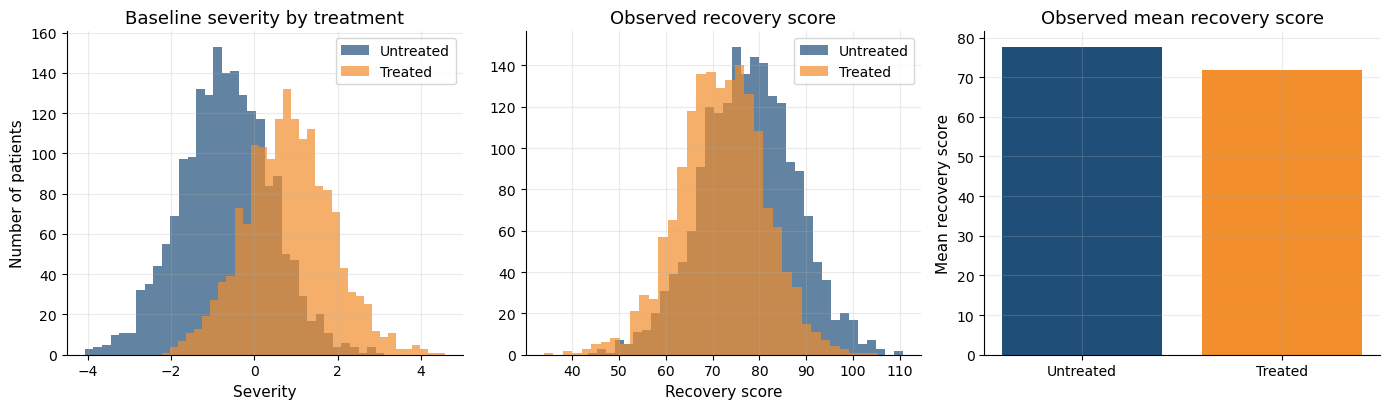

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].hist(
    health.loc[health["Treatment"] == 0, "Severity"],
    bins=35, alpha=0.70, label="Untreated", color=COLORS["navy"]
)
axes[0].hist(
    health.loc[health["Treatment"] == 1, "Severity"],
    bins=35, alpha=0.70, label="Treated", color=COLORS["orange"]
)
axes[0].set_title("Baseline severity by treatment")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Number of patients")
axes[0].legend()
clean_axis(axes[0])

axes[1].hist(
    health.loc[health["Treatment"] == 0, "RecoveryScore"],
    bins=35, alpha=0.70, label="Untreated", color=COLORS["navy"]
)
axes[1].hist(
    health.loc[health["Treatment"] == 1, "RecoveryScore"],
    bins=35, alpha=0.70, label="Treated", color=COLORS["orange"]
)
axes[1].set_title("Observed recovery score")
axes[1].set_xlabel("Recovery score")
axes[1].legend()
clean_axis(axes[1])

mean_scores = health.groupby("Treatment")["RecoveryScore"].mean()
axes[2].bar(
    ["Untreated", "Treated"],
    mean_scores.values,
    color=[COLORS["navy"], COLORS["orange"]]
)
axes[2].set_title("Observed mean recovery score")
axes[2].set_ylabel("Mean recovery score")
clean_axis(axes[2])

plt.tight_layout()
plt.show()


### Interpretation

The first plot shows that treated patients tend to have higher baseline severity. The second and third plots show that treated patients have lower observed recovery scores.

This creates the main teaching tension of the chapter:

- treated patients look worse in the observed data;
- but treated patients also started from a worse baseline condition;
- therefore, the observed comparison may point in the wrong causal direction.

A credible causal workflow must move from raw comparison to explicit causal design.


</br>

---
## 3. Causal intelligence workflow: from dataset to credible causal claim

Applied causal analysis should not start with an algorithm. It should start with a workflow.

The workflow used in this chapter has nine steps:

| Step | Main question | Output |
|---|---|---|
| 1. Formulate the causal question | What causal question are we asking? | Clear causal question |
| 2. Define unit, treatment, outcome, and time order | What is being intervened on, for whom, and when? | Unit, treatment, outcome, timeline |
| 3. Audit the variables | What role might each variable play? | Variable audit table |
| 4. Build candidate causal graphs | What causal structures are plausible? | One or more candidate DAGs |
| 5. Use causal discovery as support | What does the data suggest about possible structure? | Data-supported graph diagnostics |
| 6. Decide identifiability | Can the causal effect be estimated from this data? | Identification decision |
| 7. Choose the estimation method | Which method fits the causal design? | Estimation strategy |
| 8. Validate and stress-test the analysis | How sensitive are the conclusions? | Robustness profile |
| 9. Report conclusions responsibly | What can we claim, and under which assumptions? | Cautious causal interpretation |


<div style="text-align: center;">
  <img src="img/CH04/Causal_Intelligence_Workflow.png" alt="Causal Intelligence Workflow" width="800"/>
</div>


<br>

---
### 3.1 Step 1: formulate the causal question

A causal analysis should start with a clear causal question, not with an algorithm.

A vague question such as:

> Is treatment related to recovery?

is not enough. This is an associational question. A clearer causal question asks what would happen under an intervention:

> What would be the average effect on recovery score if patients were assigned treatment instead of no treatment?

A useful causal question defines four elements:

| Element | Meaning | Running example |
|---|---|---|
| Unit | Who or what is analyzed? | Patient |
| Treatment / exposure | What could be changed? | `Treatment` |
| Outcome | What result matters? | `RecoveryScore` |
| Contrast | Compared with what alternative? | Treatment vs. no treatment |

For the running example, the target estimand is:

$$ATE = E[RecoveryScore(1) - RecoveryScore(0)]$$

or:

$$ATE = E[RecoveryScore \mid do(Treatment=1)] - E[RecoveryScore \mid do(Treatment=0)]$$


In [5]:
causal_question = pd.DataFrame({
    "Item": [
        "Unit",
        "Treatment",
        "Treatment contrast",
        "Outcome",
        "Estimand",
        "Question",
    ],
    "Definition": [
        "Patient",
        "Treatment",
        "Treatment = 1 versus Treatment = 0",
        "RecoveryScore",
        "Average Treatment Effect (ATE)",
        "What would be the average effect on recovery score if patients were assigned treatment instead of no treatment?",
    ]
})

display_df(causal_question)


,Item,Definition
0,Unit,Patient
1,Treatment,Treatment
2,Treatment contrast,Treatment = 1 versus Treatment = 0
3,Outcome,RecoveryScore
4,Estimand,Average Treatment Effect (ATE)
5,Question,What would be the average effect on recovery s...


This table above records the causal question before any modeling begins. At this stage, we have only defined the question. We have not yet shown that the effect can be identified from the observed data. That requires the next steps.

#### Quick check: observed association

As a first diagnostic, we compute the observed difference:

$E[Y \mid T=1] - E[Y \mid T=0]$

This is easy to calculate, but it is not automatically causal.


In [6]:
mean_treated = health.loc[health["Treatment"] == 1, "RecoveryScore"].mean()
mean_untreated = health.loc[health["Treatment"] == 0, "RecoveryScore"].mean()
naive_difference = mean_treated - mean_untreated

print(f"E[RecoveryScore | Treatment=1]: {mean_treated:.3f}")
print(f"E[RecoveryScore | Treatment=0]: {mean_untreated:.3f}")
print(f"Observed difference: {naive_difference:.3f}")


E[RecoveryScore | Treatment=1]: 71.857
E[RecoveryScore | Treatment=0]: 77.675
Observed difference: -5.818


#### Interpretation

The observed mean recovery score is **71.857** among treated patients and **77.675** among untreated patients. The naive observed difference is:

$$71.857 - 77.675 = -5.818$$

This suggests that treated patients have lower recovery scores in the observed data. However, this is not yet evidence that the treatment is harmful.

From the earlier diagnostic, treated patients have much higher baseline severity. Therefore, the negative observed difference likely mixes the treatment effect with baseline clinical differences.

Step 1 defines the causal question. It does not answer it yet.

</pr>

---
### 3.2 Step 2: define the unit, treatment, outcome, and time order

After formulating the causal question, we define the basic structure of the study.

Time order matters. A variable measured before treatment can be a confounder. A variable measured after treatment may be a mediator or downstream consequence. These roles lead to different modeling choices.

For the running healthcare example, we define:

| Component | Definition |
|---|---|
| Unit of analysis | One patient |
| Treatment | `Treatment` |
| Treatment contrast | `Treatment = 1` versus `Treatment = 0` |
| Outcome | `RecoveryScore` |
| Outcome meaning | Higher values mean better recovery |
| Study type | Observational study |
| Main challenge | Treatment is not randomly assigned |


A simple time order for the variables is:

| Time stage | Variables | Interpretation |
|---|---|---|
| Before treatment | `Age`, `Socioeconomic`, `Access`, `Severity`, `Biomarker`, `HospitalPolicy` | Baseline/context variables |
| Treatment decision | `Treatment` | Intervention or exposure of interest |
| After treatment | `Inflammation`, `RecoveryScore`, `Recovery` | Downstream variables |
| Selection process | `SpecialistClinic` | Indicator of whether a patient appears in a specialist-clinic subset |

This time ordering does not prove the causal graph, but it gives useful constraints. For example, `RecoveryScore` cannot cause baseline `Severity`, and `Inflammation` should not be treated as an ordinary pre-treatment control if it is measured after treatment.

The goal of Step 2 is:

> Define what is being changed, what outcome is measured, for which units, and in what temporal order.


#### Visual timeline

The next figure summarizes the time order. It reminds us not to treat all variables as ordinary controls.


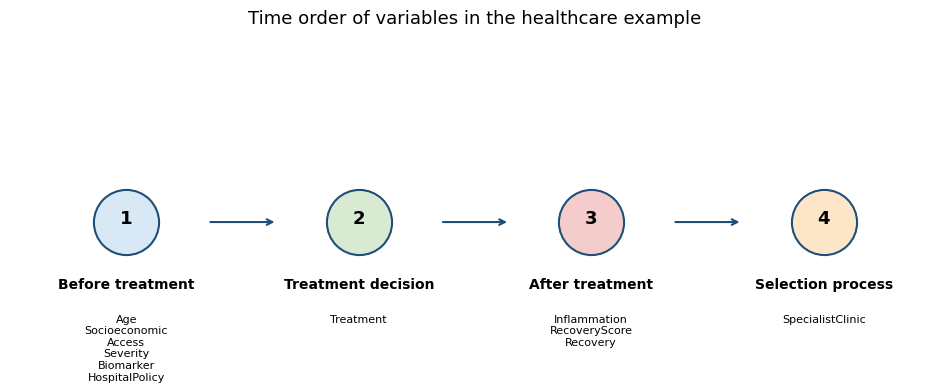

In [7]:
timeline = [
    ("Before treatment", ["Age", "Socioeconomic", "Access", "Severity", "Biomarker", "HospitalPolicy"], COLORS["light_blue"]),
    ("Treatment decision", ["Treatment"], COLORS["light_green"]),
    ("After treatment", ["Inflammation", "RecoveryScore", "Recovery"], COLORS["light_red"]),
    ("Selection process", ["SpecialistClinic"], COLORS["light_orange"]),
]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 1.2)

for i, (stage, vars_, color) in enumerate(timeline):
    ax.scatter(i, 0, s=2200, color=color, edgecolor=COLORS["navy"], linewidth=1.5)
    ax.text(i, 0.02, str(i + 1), ha="center", va="center", fontsize=13, fontweight="bold")
    ax.text(i, -0.35, stage, ha="center", va="top", fontsize=10, fontweight="bold")
    ax.text(i, -0.58, "\n".join(vars_), ha="center", va="top", fontsize=8)
    if i < len(timeline) - 1:
        ax.annotate("", xy=(i + 0.65, 0), xytext=(i + 0.35, 0),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color=COLORS["navy"]))

ax.set_title("Time order of variables in the healthcare example")
ax.axis("off")
plt.show()


#### Quick diagnostic: treatment assignment and baseline severity

If treatment were randomized, baseline severity should be similar in the treated and untreated groups. Since this is an observational dataset, we check whether severity differs by treatment status.

In [8]:
severity_by_treatment = health.groupby("Treatment").agg(
    patients=("Severity", "size"),
    mean_severity=("Severity", "mean"),
    std_severity=("Severity", "std"),
    mean_biomarker=("Biomarker", "mean"),
    mean_recovery_score=("RecoveryScore", "mean")
)

display_df(severity_by_treatment)


,patients,mean_severity,std_severity,mean_biomarker,mean_recovery_score
Treatment,,,,,
0,1903,-0.680,1.096,-0.760,77.675
1,1597,0.825,1.041,0.988,71.857


#### Interpretation

The table confirms that treatment assignment is not random.

The treated group has much higher average severity: **0.825** compared with **-0.680** in the untreated group. The treated group also has a higher average biomarker value: **0.988** compared with **-0.760**.

At the same time, the treated group has a lower average recovery score: **71.857** compared with **77.675**.

This pattern is exactly why time order matters. `Severity` and `Biomarker` are measured before treatment and are related to treatment assignment. They are therefore plausible adjustment candidates.


</pr>

---
### 3.3 Step 3: audit the variables

A variable audit means assigning each variable a possible causal role before choosing an adjustment set or fitting a model.

Causal analysis is not about controlling for as many variables as possible. Some variables should be adjusted for, while others should usually be avoided depending on the estimand.

The goal of Step 3 is:

> Decide what each variable might represent in the causal system before deciding what to control for.


In [9]:
variable_audit = pd.DataFrame({
    "Variable": [
        "Age", "Socioeconomic", "Access", "Severity", "Biomarker", "HospitalPolicy",
        "Treatment", "Inflammation", "SpecialistClinic", "RecoveryScore", "Recovery",
    ],
    "Time order": [
        "Before treatment", "Before treatment", "Before treatment", "Before treatment", "Before treatment", "Before treatment",
        "Treatment decision", "After treatment", "Selection process", "After treatment", "After treatment",
    ],
    "Possible causal role": [
        "Background covariate", "Background covariate / possible confounder", "Context variable / possible selection factor",
        "Possible confounder", "Possible confounder or proxy for clinical state", "Treatment-assignment factor",
        "Treatment / intervention", "Possible mediator", "Possible collider or selection variable", "Main outcome", "Auxiliary outcome",
    ],
    "Use for total-effect adjustment?": [
        "Consider", "Consider", "Usually not needed unless linked to treatment/outcome", "Consider", "Consider", "Consider if it affects treatment assignment",
        "No; this is the treatment", "No; post-treatment mediator", "No; selection/collider risk", "No; this is the outcome", "No; auxiliary outcome",
    ]
})

display_df(variable_audit)


,Variable,Time order,Possible causal role,Use for total-effect adjustment?
0,Age,Before treatment,Background covariate,Consider
1,Socioeconomic,Before treatment,Background covariate / possible confounder,Consider
2,Access,Before treatment,Context variable / possible selection factor,Usually not needed unless linked to treatment/...
3,Severity,Before treatment,Possible confounder,Consider
4,Biomarker,Before treatment,Possible confounder or proxy for clinical state,Consider
5,HospitalPolicy,Before treatment,Treatment-assignment factor,Consider if it affects treatment assignment
6,Treatment,Treatment decision,Treatment / intervention,No; this is the treatment
7,Inflammation,After treatment,Possible mediator,No; post-treatment mediator
8,SpecialistClinic,Selection process,Possible collider or selection variable,No; selection/collider risk
9,RecoveryScore,After treatment,Main outcome,No; this is the outcome


#### Interpretation

The audit separates variables by timing and possible causal role.

For the total effect of `Treatment` on `RecoveryScore`, the most important candidates for adjustment are pre-treatment variables that may affect treatment assignment and recovery. In this example, these include `Severity`, `Biomarker`, `Age`, `Socioeconomic`, and possibly `HospitalPolicy`.

`Inflammation` is measured after treatment and may be a mediator. Adjusting for it would block part of the treatment effect and change the estimand.

`SpecialistClinic` is a possible selection variable. Restricting the analysis to specialist-clinic patients, or controlling for clinic selection without care, may introduce collider or selection bias.

The audit does not prove the graph. It gives a structured starting point for building candidate causal graphs.

#### Quick diagnostic: correlations with treatment and outcome

Correlations do not identify causal roles, but they help us inspect which variables may matter for treatment assignment or recovery. Variables correlated with both `Treatment` and `RecoveryScore` may be possible confounders, but this must be checked against time order and domain knowledge. 


In [10]:
numeric_vars = [
    "Age", "Socioeconomic", "Access", "Severity", "Biomarker", "HospitalPolicy",
    "Inflammation", "SpecialistClinic", "RecoveryScore", "Recovery",
]

diagnostic_rows = []
for var in numeric_vars:
    diagnostic_rows.append({
        "Variable": var,
        "Corr(variable, Treatment)": health[[var, "Treatment"]].corr().iloc[0, 1],
        "Corr(variable, RecoveryScore)": health[[var, "RecoveryScore"]].corr().iloc[0, 1],
    })

correlation_diagnostics = pd.DataFrame(diagnostic_rows)
display_df(correlation_diagnostics.round(3))


,Variable,"Corr(variable, Treatment)","Corr(variable, RecoveryScore)"
0,Age,0.217,-0.396
1,Socioeconomic,-0.270,0.486
2,Access,-0.003,0.028
3,Severity,0.574,-0.856
4,Biomarker,0.555,-0.700
5,HospitalPolicy,0.112,0.071
6,Inflammation,0.312,-0.732
7,SpecialistClinic,0.281,-0.372
8,RecoveryScore,-0.286,1.000
9,Recovery,-0.141,0.464


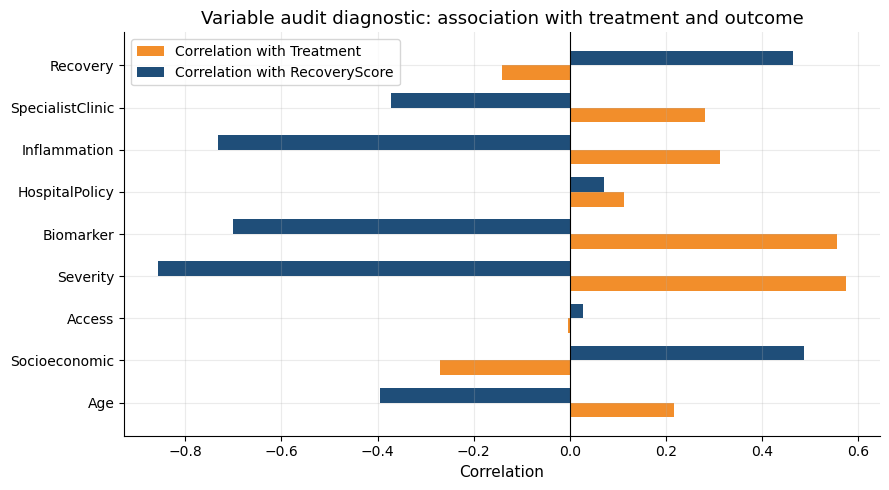

In [11]:
plot_df = correlation_diagnostics.copy()
plot_df = plot_df[~plot_df["Variable"].isin(["RecoveryScore"])]

fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(len(plot_df))
width = 0.35

ax.barh(ypos - width/2, plot_df["Corr(variable, Treatment)"], height=width, color=COLORS["orange"], label="Correlation with Treatment")
ax.barh(ypos + width/2, plot_df["Corr(variable, RecoveryScore)"], height=width, color=COLORS["navy"], label="Correlation with RecoveryScore")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["Variable"])
ax.set_xlabel("Correlation")
ax.set_title("Variable audit diagnostic: association with treatment and outcome")
ax.legend()
clean_axis(ax)
plt.tight_layout()
plt.show()


#### Interpretation

The correlation diagnostics support the concerns from the variable audit.

- `Severity` is strongly correlated with both `Treatment` (**0.574**) and `RecoveryScore` (**-0.856**). This makes it a strong candidate confounder.

- `Biomarker` is also correlated with both `Treatment` (**0.555**) and `RecoveryScore` (**-0.700**), so it may help adjust for baseline clinical condition.

- `Inflammation` is correlated with both `Treatment` (**0.312**) and `RecoveryScore` (**-0.732**), but it is measured after treatment. It should not automatically be included as a control when estimating the total treatment effect.

- `Access` is almost uncorrelated with `Treatment` (**-0.003**) and weakly correlated with `RecoveryScore` (**0.028**). It may still matter for selection into `SpecialistClinic`, but it does not appear central for the main treatment-effect estimate.


</pr>

---
### 3.4 Step 4: build candidate causal graphs

After the variable audit, we translate assumptions into one or more candidate causal graphs.

A candidate graph is not the true graph. It is a transparent statement of what we currently believe may be happening in the system.


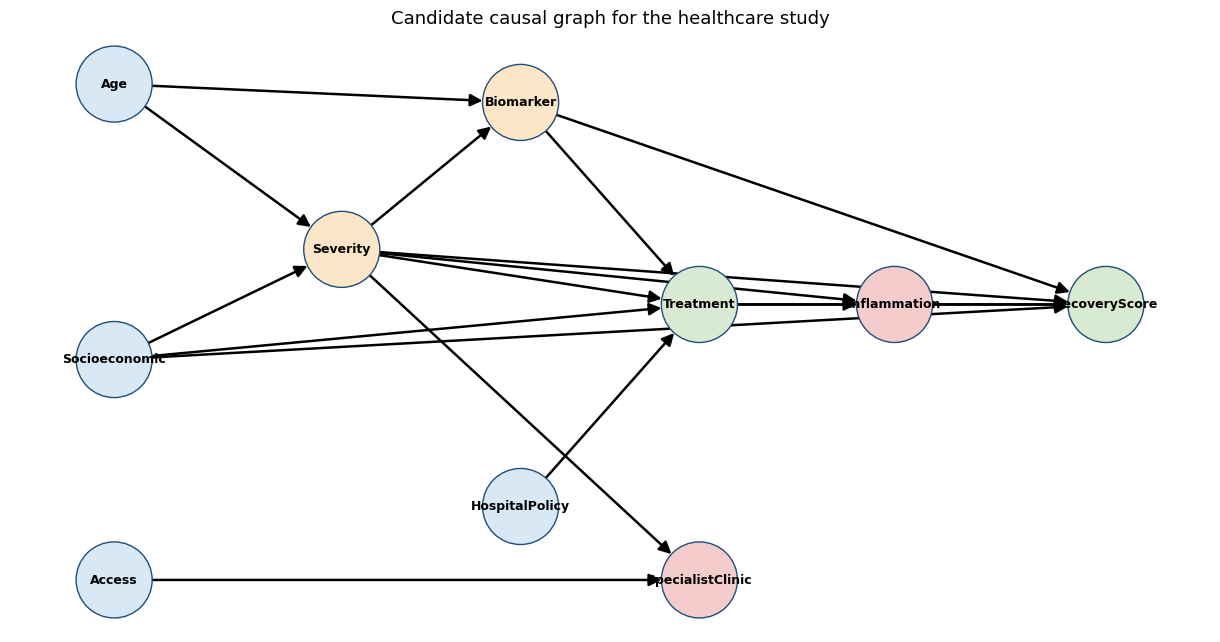

In [12]:
candidate_edges = [
    ("Age", "Severity"),
    ("Age", "Biomarker"),
    ("Socioeconomic", "Severity"),
    ("Socioeconomic", "Treatment"),
    ("Socioeconomic", "RecoveryScore"),
    ("Severity", "Biomarker"),
    ("Severity", "Treatment"),
    ("Severity", "RecoveryScore"),
    ("Biomarker", "Treatment"),
    ("Biomarker", "RecoveryScore"),
    ("HospitalPolicy", "Treatment"),
    ("Treatment", "Inflammation"),
    ("Treatment", "RecoveryScore"),
    ("Severity", "Inflammation"),
    ("Inflammation", "RecoveryScore"),
    ("Access", "SpecialistClinic"),
    ("Severity", "SpecialistClinic"),
]

candidate_pos = {
    "Age": (-2.8, 1.3),
    "Socioeconomic": (-2.8, -0.2),
    "Access": (-2.8, -1.4),
    "Severity": (-1.4, 0.4),
    "Biomarker": (-0.3, 1.2),
    "HospitalPolicy": (-0.3, -1.0),
    "Treatment": (0.8, 0.1),
    "Inflammation": (2.0, 0.1),
    "RecoveryScore": (3.3, 0.1),
    "SpecialistClinic": (0.8, -1.4),
}

candidate_node_colors = {
    "Age": COLORS["light_blue"],
    "Socioeconomic": COLORS["light_blue"],
    "Access": COLORS["light_blue"],
    "Severity": COLORS["light_orange"],
    "Biomarker": COLORS["light_orange"],
    "HospitalPolicy": COLORS["light_blue"],
    "Treatment": COLORS["light_green"],
    "Inflammation": COLORS["light_red"],
    "RecoveryScore": COLORS["light_green"],
    "SpecialistClinic": COLORS["light_red"],
}

G_candidate = draw_dag(
    candidate_edges,
    pos=candidate_pos,
    title="Candidate causal graph for the healthcare study",
    node_colors=candidate_node_colors,
    figsize=(12, 6)
)


#### Interpretation

The candidate graph makes the assumptions visible.

- `Severity`, `Biomarker`, `Socioeconomic`, and `HospitalPolicy` may influence treatment assignment. Some of these variables may also influence `RecoveryScore`, so they are possible sources of confounding.

- `Treatment` may affect `RecoveryScore` directly and may also affect `Inflammation`. Since `Inflammation` is measured after treatment, it is a possible mediator. If the goal is the total effect, we should not automatically adjust for it.

- `SpecialistClinic` is treated as a possible selection variable because it may depend on both `Severity` and `Access`.


#### Candidate adjustment set from the graph

For the total effect of `Treatment` on `RecoveryScore`, we want to block backdoor paths into `Treatment` without blocking causal paths from `Treatment` to `RecoveryScore`.

Based on the candidate graph, a preliminary adjustment set is:

`Age`, `Socioeconomic`, `Severity`, `Biomarker`, `HospitalPolicy`

Variables to avoid for total-effect estimation include:

`Inflammation`, `SpecialistClinic`, `RecoveryScore`, `Recovery`

> This adjustment set is still based on assumptions. In real research, it should be checked with domain knowledge, temporal logic, sensitivity analysis, and possibly causal discovery diagnostics.

In [13]:
candidate_adjustment_set = ["Age", "Socioeconomic", "Severity", "Biomarker", "HospitalPolicy"]
avoid_for_total_effect = ["Inflammation", "SpecialistClinic", "RecoveryScore", "Recovery"]

adjustment_summary = pd.DataFrame({
    "Variable group": ["Candidate adjustment set", "Avoid for total-effect estimation"],
    "Variables": [", ".join(candidate_adjustment_set), ", ".join(avoid_for_total_effect)],
    "Reason": [
        "Pre-treatment variables that may explain treatment assignment and recovery.",
        "Post-treatment, selection, or outcome variables that may change the estimand or introduce bias.",
    ]
})

display_df(adjustment_summary)


,Variable group,Variables,Reason
0,Candidate adjustment set,"Age, Socioeconomic, Severity, Biomarker, Hospi...",Pre-treatment variables that may explain treat...
1,Avoid for total-effect estimation,"Inflammation, SpecialistClinic, RecoveryScore,...","Post-treatment, selection, or outcome variable..."


#### Alternative graph

In real research, we rarely know the graph with certainty. Here we compare one alternative graph where `Biomarker` is treated mainly as a proxy of `Severity`, rather than as a direct cause of recovery.

When the graph is uncertain, a good practice is to ask:

- Which edges are strongly supported by domain knowledge?
- Which edges are uncertain?
- Which uncertain edges matter for identification?
- Does the estimated effect change under plausible alternative graphs?


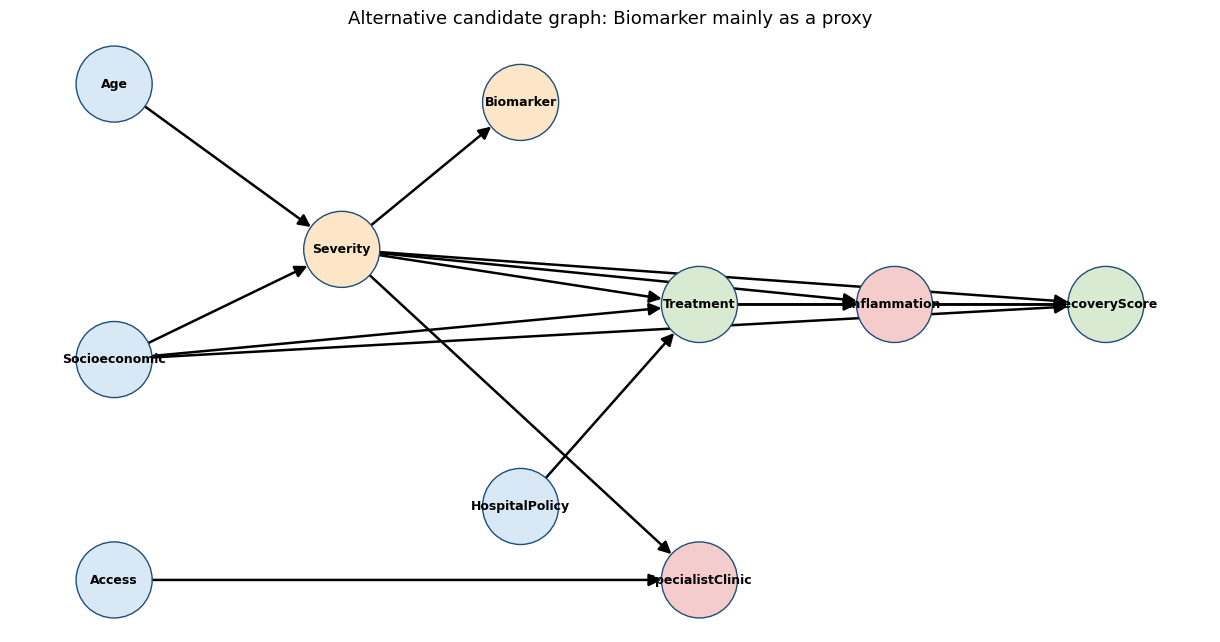

In [14]:
alternative_edges = [
    ("Age", "Severity"),
    ("Socioeconomic", "Severity"),
    ("Socioeconomic", "Treatment"),
    ("Socioeconomic", "RecoveryScore"),
    ("Severity", "Biomarker"),
    ("Severity", "Treatment"),
    ("Severity", "RecoveryScore"),
    ("HospitalPolicy", "Treatment"),
    ("Treatment", "Inflammation"),
    ("Treatment", "RecoveryScore"),
    ("Severity", "Inflammation"),
    ("Inflammation", "RecoveryScore"),
    ("Access", "SpecialistClinic"),
    ("Severity", "SpecialistClinic"),
]

G_alternative = draw_dag(
    alternative_edges,
    pos=candidate_pos,
    title="Alternative candidate graph: Biomarker mainly as a proxy",
    node_colors=candidate_node_colors,
    figsize=(12, 6)
)


#### Step 4 output

At the end of Step 4, we have:

| Output | Description |
|---|---|
| Candidate graph | A first DAG representing our assumptions |
| Alternative graph | A simplified competing DAG for uncertain assumptions |
| Candidate adjustment set | `Age`, `Socioeconomic`, `Severity`, `Biomarker`, `HospitalPolicy` |
| Variables to avoid | `Inflammation`, `SpecialistClinic`, `RecoveryScore`, `Recovery` |

The adjustment set comes from the causal question and graph, not from automatic feature selection.


</pr>

---
### 3.5 Step 5: use causal discovery as a support tool

After building candidate graphs, we use data-driven diagnostics to see whether the observed data are broadly consistent with some of our assumptions.

Causal discovery should not be treated as automatic causal truth. Here it is a support tool for graph refinement.

The goal of Step 5 is:

> Use data-driven diagnostics to refine candidate graphs, not to replace causal thinking.


#### Simple discovery-style diagnostic

We start by computing a correlation matrix among the main observed variables.

Correlation does not imply causation, but it helps us see which variables are statistically related. 

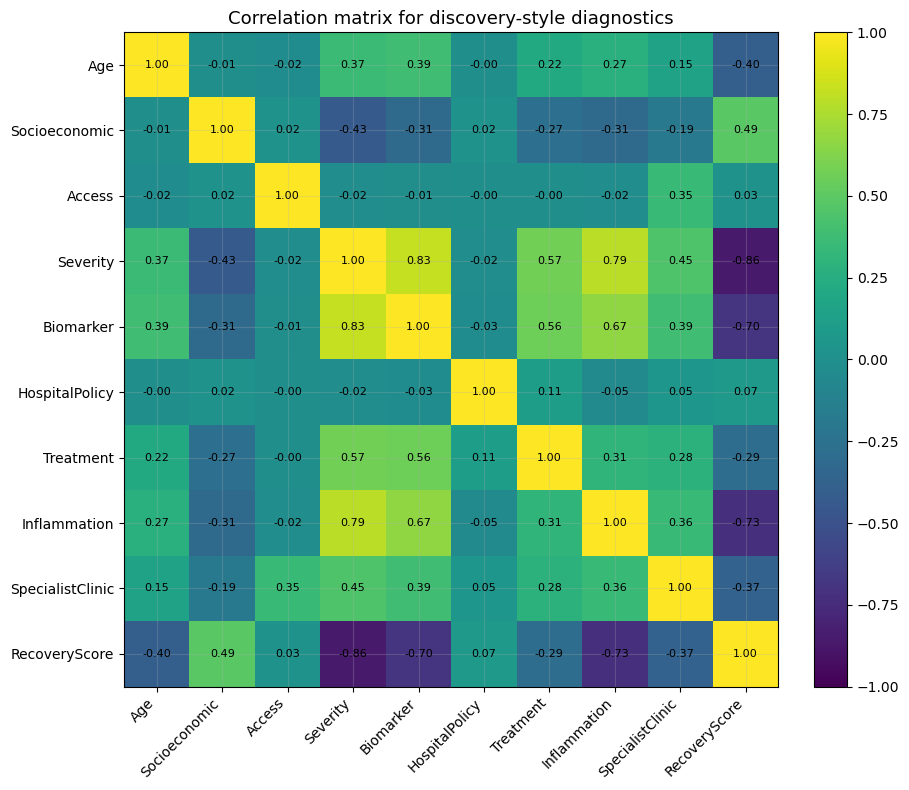

In [15]:
discovery_vars = [
    "Age", "Socioeconomic", "Access", "Severity", "Biomarker", "HospitalPolicy",
    "Treatment", "Inflammation", "SpecialistClinic", "RecoveryScore",
]

corr_matrix = health[discovery_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(discovery_vars)))
ax.set_yticks(np.arange(len(discovery_vars)))
ax.set_xticklabels(discovery_vars, rotation=45, ha="right")
ax.set_yticklabels(discovery_vars)

for i in range(len(discovery_vars)):
    for j in range(len(discovery_vars)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation matrix for discovery-style diagnostics")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


#### Interpretation

The correlation matrix is a first diagnostic view of the data.

- We expect variables such as `Severity`, `Biomarker`, `Treatment`, `Inflammation`, and `RecoveryScore` to show visible associations because they are part of the clinical process in the running example.

- However, the matrix should be interpreted carefully. A correlation between `Treatment` and `RecoveryScore` does not tell us whether treatment caused recovery. It may reflect confounding by severity or biomarker values. 


#### Partial-correlation diagnostics

A central idea in graph-based causal discovery is conditional independence. 

For example, if two variables are associated at first, but their association becomes weak after conditioning on a third variable, this may suggest that the third variable explains part of the relationship.

The table below compares several associations before and after conditioning.


In [16]:
pc_examples = [
    {
        "X": "Treatment",
        "Y": "RecoveryScore",
        "Conditioning set": [],
        "Question": "Raw treatment-outcome association",
    },
    {
        "X": "Treatment",
        "Y": "RecoveryScore",
        "Conditioning set": candidate_adjustment_set,
        "Question": "Treatment-outcome association after baseline adjustment",
    },
    {
        "X": "Severity",
        "Y": "Treatment",
        "Conditioning set": [],
        "Question": "Is severity related to treatment assignment?",
    },
    {
        "X": "Severity",
        "Y": "RecoveryScore",
        "Conditioning set": [],
        "Question": "Is severity related to recovery?",
    },
    {
        "X": "Access",
        "Y": "Severity",
        "Conditioning set": [],
        "Question": "Access-severity association in full data",
    },
    {
        "X": "Access",
        "Y": "Severity",
        "Conditioning set": ["SpecialistClinic"],
        "Question": "Access-severity association after conditioning on selection",
    },
]

pc_rows = []
for ex in pc_examples:
    controls = ex["Conditioning set"]
    pc_rows.append({
        "Question": ex["Question"],
        "X": ex["X"],
        "Y": ex["Y"],
        "Conditioning set": ", ".join(controls) if controls else "None",
        "Correlation / partial correlation": partial_corr(health, ex["X"], ex["Y"], controls),
    })

pc_results = pd.DataFrame(pc_rows)
display_df(pc_results.round(3))


,Question,X,Y,Conditioning set,Correlation / partial correlation
0,Raw treatment-outcome association,Treatment,RecoveryScore,None,-0.286
1,Treatment-outcome association after baseline a...,Treatment,RecoveryScore,"Age, Socioeconomic, Severity, Biomarker, Hospi...",0.521
2,Is severity related to treatment assignment?,Severity,Treatment,None,0.574
3,Is severity related to recovery?,Severity,RecoveryScore,None,-0.856
4,Access-severity association in full data,Access,Severity,None,-0.023
5,Access-severity association after conditioning...,Access,Severity,SpecialistClinic,-0.214


Here we use a simple partial-correlation function. It removes the linear association with a conditioning set and then computes the correlation between the remaining residuals. 

This is a **linear** partial-correlation diagnostic. It may miss nonlinear relationships, and it should not be interpreted as formal causal discovery.

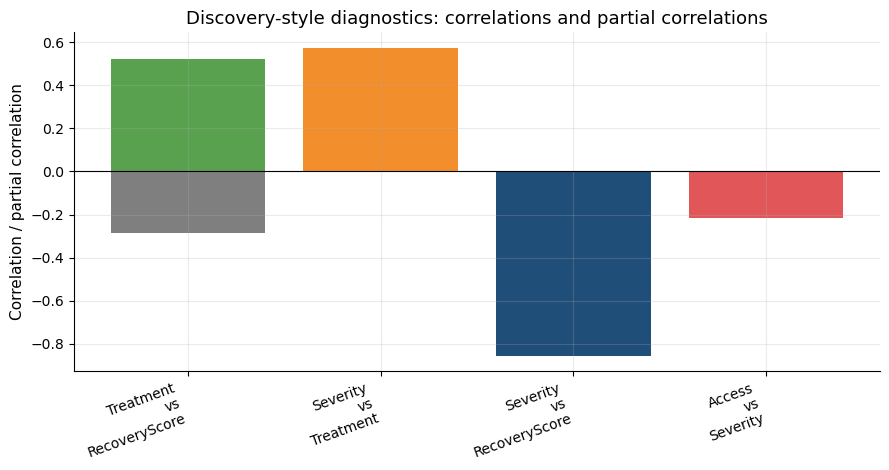

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.8))
labels = [f"{row.X}\nvs\n{row.Y}" for _, row in pc_results.iterrows()]
values = pc_results["Correlation / partial correlation"].values
colors = [COLORS["gray"], COLORS["green"], COLORS["orange"], COLORS["navy"], COLORS["gray"], COLORS["red"]]

ax.bar(labels, values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Discovery-style diagnostics: correlations and partial correlations")
ax.set_ylabel("Correlation / partial correlation")
plt.xticks(rotation=20, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()


#### Interpretation

The diagnostics are consistent with the causal story.

- The raw association between `Treatment` and `RecoveryScore` is negative: **-0.286**. After conditioning on baseline variables, it becomes positive: **0.521**. This large change suggests that the raw treatment comparison was strongly affected by baseline differences.

- `Severity` is strongly associated with treatment assignment (**0.574**) and strongly negatively associated with recovery (**-0.856**). This supports the role of `Severity` as a major confounding variable.

- The selection example also behaves as expected. `Access` and `Severity` are nearly unrelated in the full data (**-0.023**), but after conditioning on `SpecialistClinic`, the association becomes more negative (**-0.214**). This is consistent with collider or selection bias.

These diagnostics support the candidate graph, but they do not prove it.


#### Simple PC-inspired skeleton

The next code creates a lightweight, teaching-oriented skeleton diagnostic. It is not a full PC algorithm. It only helps students see which variable pairs remain connected under simple marginal and one-variable conditional checks.


In [18]:
def pc_inspired_skeleton(df, variables, marginal_threshold=0.08, conditional_threshold=0.05):
    kept_edges = []
    removed_rows = []

    for i, x in enumerate(variables):
        for y in variables[i + 1:]:
            r_xy = partial_corr(df, x, y)

            if abs(r_xy) < marginal_threshold:
                removed_rows.append({
                    "X": x,
                    "Y": y,
                    "Reason": "Weak marginal association",
                    "Separating variable": "None",
                    "Marginal corr": r_xy,
                    "Partial corr": np.nan,
                })
                continue

            remove_edge = False
            best_sep = None
            best_pcorr = None

            for z in variables:
                if z in [x, y]:
                    continue
                r_xy_z = partial_corr(df, x, y, [z])
                if abs(r_xy_z) < conditional_threshold:
                    remove_edge = True
                    best_sep = z
                    best_pcorr = r_xy_z
                    break

            if remove_edge:
                removed_rows.append({
                    "X": x,
                    "Y": y,
                    "Reason": "Weak after conditioning",
                    "Separating variable": best_sep,
                    "Marginal corr": r_xy,
                    "Partial corr": best_pcorr,
                })
            else:
                kept_edges.append((x, y))

    return kept_edges, pd.DataFrame(removed_rows)

skeleton_vars = [
    "Age", "Socioeconomic", "Severity", "Biomarker", "HospitalPolicy",
    "Treatment", "Inflammation", "RecoveryScore",
]

skeleton_edges, removed_edges = pc_inspired_skeleton(
    health,
    skeleton_vars,
    marginal_threshold=0.08,
    conditional_threshold=0.05,
)

print("Retained undirected edges:")
for edge in skeleton_edges:
    print(edge)


Retained undirected edges:
('Age', 'Severity')
('Age', 'Biomarker')
('Age', 'RecoveryScore')
('Socioeconomic', 'Biomarker')
('Socioeconomic', 'Inflammation')
('Socioeconomic', 'RecoveryScore')
('Severity', 'Biomarker')
('Severity', 'Treatment')
('Severity', 'Inflammation')
('Severity', 'RecoveryScore')
('Biomarker', 'Treatment')
('HospitalPolicy', 'Treatment')
('Treatment', 'Inflammation')
('Treatment', 'RecoveryScore')
('Inflammation', 'RecoveryScore')


#### Visualizing the discovered skeleton

The next plot shows the retained undirected edges from the simple skeleton diagnostic.

Because the graph is undirected, it does not claim causal direction. It only shows which variable pairs remain connected under this simple procedure.

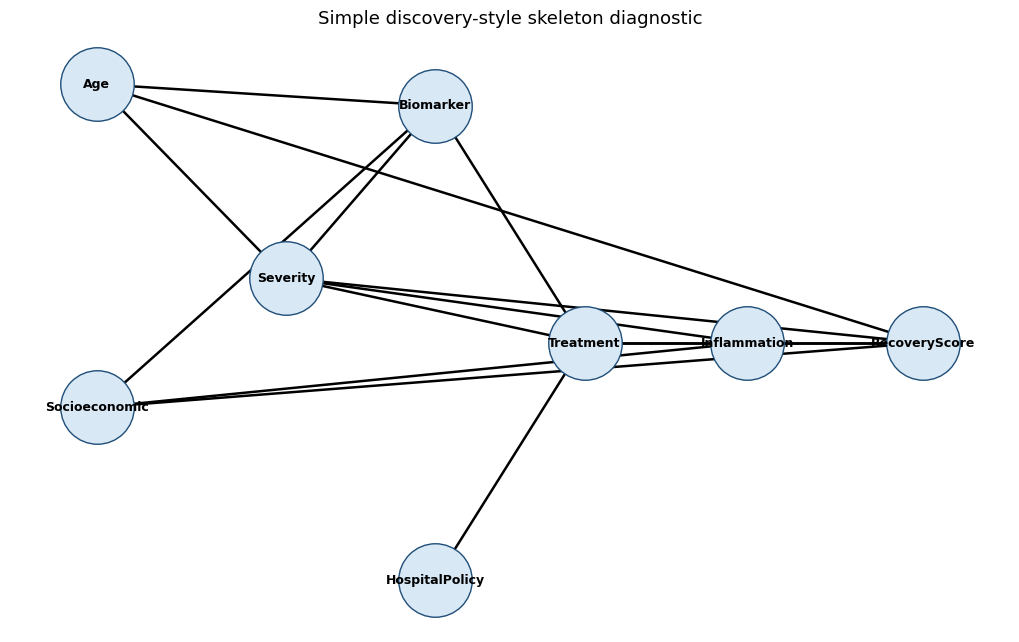

In [19]:
G_skeleton = nx.Graph()
G_skeleton.add_nodes_from(skeleton_vars)
G_skeleton.add_edges_from(skeleton_edges)

plt.figure(figsize=(10, 6))
nx.draw(
    G_skeleton,
    pos={node: candidate_pos[node] for node in skeleton_vars},
    with_labels=True,
    node_size=2800,
    node_color=COLORS["light_blue"],
    edgecolors=COLORS["navy"],
    font_size=9,
    font_weight="bold",
    width=1.8,
)
plt.title("Simple discovery-style skeleton diagnostic")
plt.axis("off")
plt.show()


#### Interpretation

The skeleton provides a data-supported view of connected variable pairs. Some retained edges agree with the candidate graph, while others may be surprising.

The correct response is not to accept the skeleton as truth. Instead, we use it to ask better questions:

- Does it support the importance of `Severity` and `Biomarker`?
- Does it support a connection between `Treatment` and `RecoveryScore` after adjustment?
- Are expected relationships missing?
- Are unexpected relationships present?

Causal discovery is useful when it improves the discussion of assumptions.


</pr>

---
### 3.6 Step 6: decide whether the effect is identifiable

Identification asks:

> Can the causal quantity we want be expressed using the variables we actually observe?

Our target is:

$$ATE = E[RecoveryScore \mid do(Treatment=1)] - E[RecoveryScore \mid do(Treatment=0)]$$

The treatment effect is identifiable by adjustment if we believe that:

1. important pre-treatment confounders are observed;
2. the adjustment set blocks the main backdoor paths from `Treatment` to `RecoveryScore`;
3. treatment happens before the outcome;
4. there is sufficient overlap between treated and untreated patients;
5. we do not adjust for mediators, colliders, or outcomes.


The goal of Step 6 is:

> Decide whether the causal effect can be estimated under explicit assumptions, and clearly state those assumptions.


#### Identification by adjustment

If the adjustment set $Z$ blocks the relevant backdoor paths, then the causal effect can be written as:

$$E[Y \mid do(T=1)] - E[Y \mid do(T=0)]$$

$$= \sum_z \left( E[Y \mid T=1, Z=z] - E[Y \mid T=0, Z=z] \right) P(Z=z)$$

where:

- $T$ is `Treatment`;
- $Y$ is `RecoveryScore`;
- $Z$ is the adjustment set.

For continuous variables, the summation is replaced by an integral. In practice, we often estimate this quantity using regression adjustment, propensity methods, doubly robust methods, or causal machine learning.

This formula is important because it connects the causal question to something we can estimate from observed data, under assumptions.

In [20]:
identification_decision = pd.DataFrame({
    "Item": [
        "Target estimand", "Identification strategy", "Adjustment set",
        "Variables avoided", "Main assumption", "Identification status"
    ],
    "Decision": [
        "Average Treatment Effect of Treatment on RecoveryScore",
        "Backdoor adjustment / adjustment for pre-treatment variables",
        ", ".join(candidate_adjustment_set),
        ", ".join(avoid_for_total_effect),
        "No important unmeasured confounders after adjustment",
        "Plausibly identifiable under the candidate graph",
    ]
})

display_df(identification_decision)


,Item,Decision
0,Target estimand,Average Treatment Effect of Treatment on Recov...
1,Identification strategy,Backdoor adjustment / adjustment for pre-treat...
2,Adjustment set,"Age, Socioeconomic, Severity, Biomarker, Hospi..."
3,Variables avoided,"Inflammation, SpecialistClinic, RecoveryScore,..."
4,Main assumption,No important unmeasured confounders after adju...
5,Identification status,Plausibly identifiable under the candidate graph


#### Interpretation

The table states the identification decision explicitly.

In this example, we proceed as if the effect is identifiable by adjusting for the selected pre-treatment variables. This does not mean the assumptions are certainly true. It means that the causal estimate will be interpreted **conditional on these assumptions**.

The most important assumption is that there are no major unmeasured confounders after adjusting for:

`Age`, `Socioeconomic`, `Severity`, `Biomarker`, and `HospitalPolicy`

#### Overlap diagnostic

Identification also requires overlap. For comparable patients, both treatment and no treatment should be possible.

We inspect overlap using an estimated propensity score:

$$e(X) = P(T=1 \mid X)$$

where $X$ is the adjustment set.


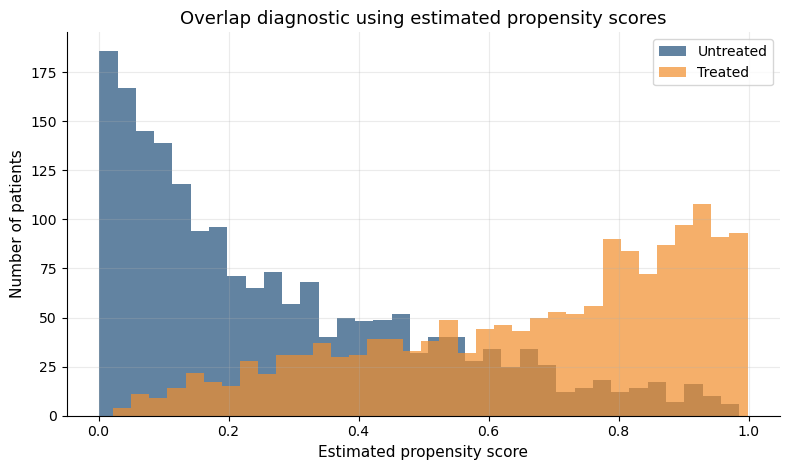

In [21]:
propensity_model = LogisticRegression(max_iter=1000)
propensity_model.fit(health[candidate_adjustment_set], health["Treatment"])

health["EstimatedPropensity"] = propensity_model.predict_proba(
    health[candidate_adjustment_set]
)[:, 1]

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.hist(
    health.loc[health["Treatment"] == 0, "EstimatedPropensity"],
    bins=35, alpha=0.70, label="Untreated", color=COLORS["navy"]
)
ax.hist(
    health.loc[health["Treatment"] == 1, "EstimatedPropensity"],
    bins=35, alpha=0.70, label="Treated", color=COLORS["orange"]
)

ax.set_title("Overlap diagnostic using estimated propensity scores")
ax.set_xlabel("Estimated propensity score")
ax.set_ylabel("Number of patients")
ax.legend()
clean_axis(ax)
plt.tight_layout()
plt.show()


#### Interpretation

The histogram shows whether treated and untreated patients occupy similar regions of the covariate space.

Good overlap means that treated and untreated patients have overlapping propensity-score distributions. This supports comparison after adjustment.

Poor overlap means that some treated patients have no comparable untreated patients, or some untreated patients have no comparable treated patients. In that case, the estimated causal effect may rely heavily on extrapolation.

Overlap is not enough to prove identification, but it is an important diagnostic. If overlap is weak, the analysis should report this limitation or restrict the target population.

In [22]:
overlap_summary = health.groupby("Treatment").agg(
    patients=("EstimatedPropensity", "size"),
    min_propensity=("EstimatedPropensity", "min"),
    q10_propensity=("EstimatedPropensity", lambda x: x.quantile(0.10)),
    median_propensity=("EstimatedPropensity", "median"),
    q90_propensity=("EstimatedPropensity", lambda x: x.quantile(0.90)),
    max_propensity=("EstimatedPropensity", "max"),
)

display_df(overlap_summary.round(3))


,patients,min_propensity,q10_propensity,median_propensity,q90_propensity,max_propensity
Treatment,,,,,,
0,1903,0.001,0.030,0.201,0.646,0.985
1,1597,0.022,0.296,0.736,0.950,0.999


#### Interpretation

The overlap summary shows partial but imperfect overlap.

Untreated patients have a median estimated propensity score of **0.201**, while treated patients have a median of **0.736**. This confirms that treated and untreated patients occupy different regions of the covariate space.

However, the ranges overlap. Untreated patients have propensity scores up to **0.985**, and treated patients have propensity scores as low as **0.022**. This means that comparison is possible, but not equally reliable everywhere.

We proceed with adjustment, but we should report that overlap is imperfect and that some estimates may rely on extrapolation.


#### Covariate balance diagnostic

A useful visual check is the standardized mean difference (SMD) between treated and untreated groups. Values closer to zero indicate better balance. Here we compare unweighted balance with balance after simple inverse-propensity weighting (IPW). In this chapter, IPW is used only as a **balance diagnostic**, not as the main treatment-effect estimator.


- SMD means **standardized mean difference**. It measures how different a covariate is between treated and untreated groups in standard deviation units.

- Values close to zero indicate better balance. A common rule of thumb is that absolute values below **0.1** indicate good balance.

- IPW means **inverse probability weighting**. It uses the estimated propensity score to give more weight to patients who are less common in their treatment group.

In [23]:
def standardized_mean_difference(df, var, treatment_col="Treatment", weights=None):
    treated = df[treatment_col] == 1
    control = df[treatment_col] == 0
    x1 = df.loc[treated, var]
    x0 = df.loc[control, var]

    if weights is None:
        m1, m0 = x1.mean(), x0.mean()
        v1, v0 = x1.var(), x0.var()
    else:
        w1 = weights[treated]
        w0 = weights[control]
        m1 = np.average(x1, weights=w1)
        m0 = np.average(x0, weights=w0)
        v1 = np.average((x1 - m1) ** 2, weights=w1)
        v0 = np.average((x0 - m0) ** 2, weights=w0)

    pooled_sd = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / pooled_sd

balance_vars = candidate_adjustment_set
ps = np.clip(health["EstimatedPropensity"].values, 0.01, 0.99)
iptw = np.where(health["Treatment"].values == 1, 1 / ps, 1 / (1 - ps))

balance_rows = []
for var in balance_vars:
    balance_rows.append({
        "Variable": var,
        "Unweighted SMD": standardized_mean_difference(health, var),
        "Weighted SMD after IPW": standardized_mean_difference(health, var, weights=iptw),
    })

balance_df = pd.DataFrame(balance_rows)
display_df(balance_df.round(3))


,Variable,Unweighted SMD,Weighted SMD after IPW
0,Age,0.447,0.026
1,Socioeconomic,-0.563,-0.038
2,Severity,1.408,0.040
3,Biomarker,1.343,0.064
4,HospitalPolicy,0.226,-0.030


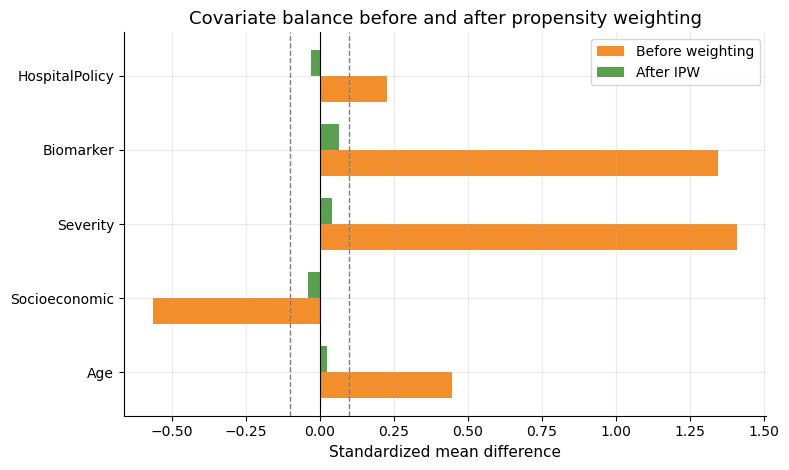

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ypos = np.arange(len(balance_df))
width = 0.35

ax.barh(ypos - width/2, balance_df["Unweighted SMD"], height=width, color=COLORS["orange"], label="Before weighting")
ax.barh(ypos + width/2, balance_df["Weighted SMD after IPW"], height=width, color=COLORS["green"], label="After IPW")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.1, color=COLORS["gray"], linewidth=1.0, linestyle="--")
ax.axvline(-0.1, color=COLORS["gray"], linewidth=1.0, linestyle="--")
ax.set_yticks(ypos)
ax.set_yticklabels(balance_df["Variable"])
ax.set_xlabel("Standardized mean difference")
ax.set_title("Covariate balance before and after propensity weighting")
ax.legend()
clean_axis(ax)
plt.tight_layout()
plt.show()


#### Interpretation

The unweighted SMDs show strong imbalance for baseline variables, especially `Severity` and `Biomarker`. This agrees with the descriptive tables.

After simple inverse-propensity weighting (IPW), the SMDs move closer to zero. This does not prove identification, but it shows that the estimated propensity score captures important differences between treated and untreated patients.

Identification is not a software output. It is an argument based on assumptions, graph structure, time order, measured variables, and overlap.


</pr>

---
### 3.7 Step 7: choose and implement estimation methods

Once the causal effect is plausibly identifiable, we choose an estimation method.

The method should match the causal design. We do not choose a method only because it is advanced or popular. We choose it because it estimates the causal quantity defined in Step 1 under the assumptions stated in Step 6.

For this chapter, we use:

| Method | Why use it? | Main limitation |
|---|---|---|
| Naive difference | Simple baseline | Confounded in observational data |
| Adjusted linear outcome model | Transparent implementation of adjustment | Depends on model specification |
| Adjusted random forest outcome model | More flexible outcome model | Still depends on causal assumptions and overlap |


In [25]:
# Step 7: estimate the treatment effect 

Y = "RecoveryScore"
T = "Treatment"
Z = candidate_adjustment_set

# 1. Naive observed difference
naive_ate = (
    health.loc[health[T] == 1, Y].mean()
    - health.loc[health[T] == 0, Y].mean()
)

# 2. Adjusted linear outcome model
outcome_model = LinearRegression()
outcome_model.fit(health[[T] + Z], health[Y])

do_treat = health.copy()
do_control = health.copy()
do_treat[T] = 1
do_control[T] = 0

y_hat_treat = outcome_model.predict(do_treat[[T] + Z])
y_hat_control = outcome_model.predict(do_control[[T] + Z])
adjusted_ate = np.mean(y_hat_treat - y_hat_control)

# 3. Flexible outcome model
rf_outcome_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=20,
    random_state=42,
)
rf_outcome_model.fit(health[[T] + Z], health[Y])
rf_y_hat_treat = rf_outcome_model.predict(do_treat[[T] + Z])
rf_y_hat_control = rf_outcome_model.predict(do_control[[T] + Z])
rf_adjusted_ate = np.mean(rf_y_hat_treat - rf_y_hat_control)

method_comparison = pd.DataFrame({
    "Estimator": [
        "Naive observed difference",
        "Adjusted linear model",
        "Adjusted random forest model",
    ],
    "Estimated ATE": [
        naive_ate,
        adjusted_ate,
        rf_adjusted_ate,
    ]
})

display_df(method_comparison.round(3))


,Estimator,Estimated ATE
0,Naive observed difference,-5.818
1,Adjusted linear model,6.467
2,Adjusted random forest model,5.055


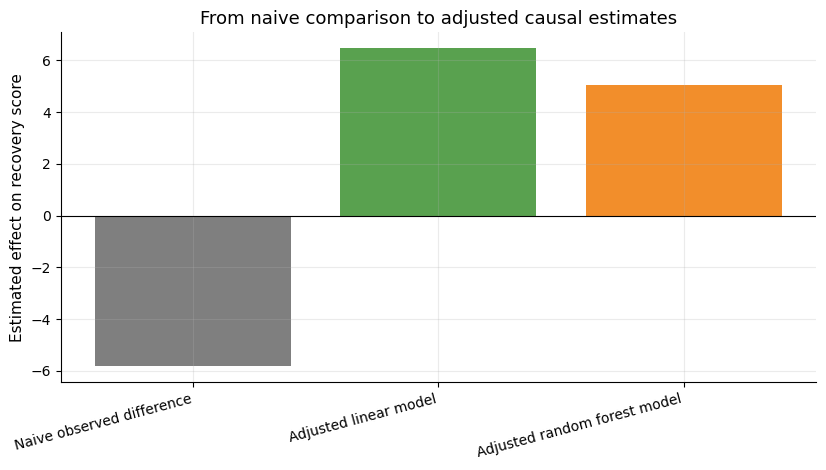

In [26]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(
    method_comparison["Estimator"],
    method_comparison["Estimated ATE"],
    color=[COLORS["gray"], COLORS["green"], COLORS["orange"]]
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("From naive comparison to adjusted causal estimates")
ax.set_ylabel("Estimated effect on recovery score")
plt.xticks(rotation=15, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()


</pr>

**Note:** For simplicity, we use the fitted random forest directly. In more advanced causal ML workflows, cross-fitting or Double Machine Learning can reduce overfitting bias. This connects to the methods discussed in Chapter 3.

#### Interpretation

- The naive observed difference is **-5.818** recovery-score points. If interpreted causally, this would suggest that treatment reduces recovery. But this is misleading because treated patients were more severe at baseline.

- After adjustment, the linear model estimates an effect of **+6.467** recovery-score points. The random forest model estimates **+5.055** recovery-score points.

The sign reversal is the main teaching point:

- raw observational comparison: treatment looks harmful;
- adjusted causal estimate: treatment looks beneficial.

Both adjusted models point in the same direction, although the magnitude differs. This means the estimated benefit is positive, but its exact size depends on the outcome model.


</pr>

---
### 3.8 Step 8: validate and stress-test the analysis

After estimating the causal effect, we should not immediately treat the result as final.

A causal estimate depends on assumptions, including the adjustment set, model choice, overlap, and the absence of major unmeasured confounding.

This step asks:

> Does the causal conclusion change when we modify reasonable parts of the analysis?

So, we use three checks:

| Check | Purpose |
|---|---|
| Alternative adjustment sets | Test sensitivity to variable selection |
| Alternative outcome models | Test sensitivity to model choice |
| Placebo-style outcome | Check whether the workflow produces suspicious effects where no effect is expected |

These checks do not prove causality. They help us understand how fragile or stable the conclusion is.


#### Check 1: alternative adjustment sets

The first stress test compares the estimated effect under different adjustment sets.

We compare:

- a minimal adjustment set;
- the main adjustment set;
- an extended adjustment set that adds `Access`;
- a problematic adjustment set that adds the post-treatment mediator `Inflammation`.

The last case is included as a warning, not as a recommended estimate.

In [27]:
# Step 8, Check 1: sensitivity to adjustment-set choice

adjustment_sets = {
    "Minimal: Severity + Biomarker": ["Severity", "Biomarker"],
    "Main adjustment set": ["Age", "Socioeconomic", "Severity", "Biomarker", "HospitalPolicy"],
    "Extended: add Access": ["Age", "Socioeconomic", "Access", "Severity", "Biomarker", "HospitalPolicy"],
    "Problematic: add Inflammation": ["Age", "Socioeconomic", "Severity", "Biomarker", "HospitalPolicy", "Inflammation"],
}

sensitivity_rows = []
for label, adj_vars in adjustment_sets.items():
    model = LinearRegression()
    model.fit(health[[T] + adj_vars], health[Y])

    do1 = health.copy()
    do0 = health.copy()
    do1[T] = 1
    do0[T] = 0

    ate_hat = (
        model.predict(do1[[T] + adj_vars]).mean()
        - model.predict(do0[[T] + adj_vars]).mean()
    )

    sensitivity_rows.append({
        "Adjustment set": label,
        "Variables": ", ".join(adj_vars),
        "Estimated ATE": ate_hat,
    })

adjustment_sensitivity = pd.DataFrame(sensitivity_rows)
display_df(adjustment_sensitivity.round(3))


,Adjustment set,Variables,Estimated ATE
0,Minimal: Severity + Biomarker,"Severity, Biomarker",6.361
1,Main adjustment set,"Age, Socioeconomic, Severity, Biomarker, Hospi...",6.467
2,Extended: add Access,"Age, Socioeconomic, Access, Severity, Biomarke...",6.466
3,Problematic: add Inflammation,"Age, Socioeconomic, Severity, Biomarker, Hospi...",6.234


#### Interpretation

The table shows how the estimated ATE changes when the adjustment set changes.

- The minimal and main adjustment sets should usually give estimates with the same general direction if the causal conclusion is stable.

- The extended set adds `Access`. If `Access` is not central to treatment assignment or recovery, the estimate may not change much.

- The problematic set includes `Inflammation`, which is measured after treatment. If this estimate is smaller or different, that is expected: adjusting for a mediator can block part of the treatment effect and change the estimand.

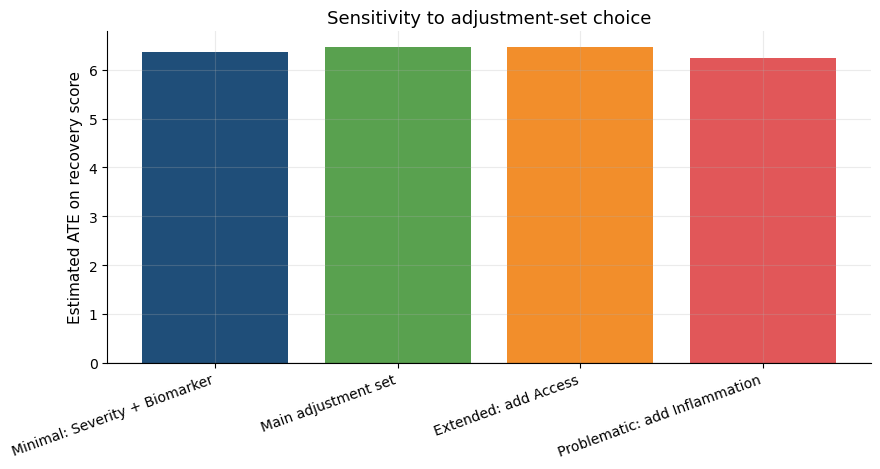

In [28]:
# Visualize adjustment-set sensitivity

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(
    adjustment_sensitivity["Adjustment set"],
    adjustment_sensitivity["Estimated ATE"],
    color=[COLORS["navy"], COLORS["green"], COLORS["orange"], COLORS["red"]]
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Sensitivity to adjustment-set choice")
ax.set_ylabel("Estimated ATE on recovery score")
plt.xticks(rotation=20, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()


#### Interpretation

The adjustment-set sensitivity results are fairly stable.

The minimal adjustment set gives an estimated ATE of **6.361**. The main adjustment set gives **6.467**. Adding `Access` gives **6.466**, almost unchanged.

The problematic mediator-adjusted model gives **6.234**, which is only slightly smaller. However, the conceptual problem remains: `Inflammation` is measured after treatment and may lie on the treatment-to-recovery pathway. Adjusting for it changes the estimand and should not be used as the main total-effect estimate.

Reasonable adjustment sets give similar positive estimates, while post-treatment adjustment should be interpreted cautiously.


#### Check 2: alternative outcome models

The second stress test compares a simple linear model with a more flexible random forest model.

Both models use the same main adjustment set. Therefore, they target the same causal estimand, but they estimate the outcome function differently.

In [29]:
# Step 8, Check 2: sensitivity to model choice

model_sensitivity = pd.DataFrame({
    "Model": ["Linear outcome model", "Random forest outcome model"],
    "Estimated ATE": [adjusted_ate, rf_adjusted_ate]
})

display_df(model_sensitivity.round(3))


,Model,Estimated ATE
0,Linear outcome model,6.467
1,Random forest outcome model,5.055


#### Interpretation

The linear outcome model estimates an ATE of **6.467**. The random forest model estimates **5.055**.

The estimates differ in magnitude, but not in direction. This means the conclusion that treatment is beneficial is reasonably stable, while the exact size of the effect is model-sensitive.


#### Check 3: Placebo-style outcome

A placebo-style check asks whether the treatment appears to affect a variable that should not be affected by treatment.

Here we use `Age` as a simple placebo outcome. Since age is measured before treatment, treatment should not causally affect it. This is not a perfect test, but it is useful as a warning signal. 


In [30]:
placebo_Y = "Age"
placebo_Z = ["Socioeconomic", "Severity", "Biomarker", "HospitalPolicy"]

placebo_model = LinearRegression()
placebo_model.fit(health[[T] + placebo_Z], health[placebo_Y])

placebo_do1 = health.copy()
placebo_do0 = health.copy()
placebo_do1[T] = 1
placebo_do0[T] = 0

placebo_effect = (
    placebo_model.predict(placebo_do1[[T] + placebo_Z]).mean()
    - placebo_model.predict(placebo_do0[[T] + placebo_Z]).mean()
)

print(f"Placebo estimated effect of Treatment on Age: {placebo_effect:.3f}")


Placebo estimated effect of Treatment on Age: -0.362


#### Interpretation

The placebo estimated effect of treatment on `Age` is **-0.362** years.

Since `Age` is measured before treatment, treatment should not causally affect it. A value close to zero is reassuring. The estimate is not exactly zero, which is expected in observational data and finite samples, but it is small compared with the scale of age variation in the dataset.


#### Stress-test summary

The next code cell collects the main robustness results into one table.

In [31]:
robustness_summary = pd.DataFrame({
    "Check": [
        "Main adjusted estimate",
        "Random forest estimate",
        "Minimal adjustment estimate",
        "Extended adjustment estimate",
        "Problematic mediator-adjusted estimate",
        "Placebo effect on Age",
    ],
    "Value": [
        adjusted_ate,
        rf_adjusted_ate,
        adjustment_sensitivity.loc[adjustment_sensitivity["Adjustment set"] == "Minimal: Severity + Biomarker", "Estimated ATE"].iloc[0],
        adjustment_sensitivity.loc[adjustment_sensitivity["Adjustment set"] == "Extended: add Access", "Estimated ATE"].iloc[0],
        adjustment_sensitivity.loc[adjustment_sensitivity["Adjustment set"] == "Problematic: add Inflammation", "Estimated ATE"].iloc[0],
        placebo_effect,
    ],
    "Interpretation": [
        "Primary estimate under candidate graph",
        "Model-choice sensitivity",
        "Adjustment-set sensitivity",
        "Sensitivity to adding Access",
        "Shows how mediator adjustment can change the estimand",
        "Should be close to zero",
    ]
})

display_df(robustness_summary.round(3))


,Check,Value,Interpretation
0,Main adjusted estimate,6.467,Primary estimate under candidate graph
1,Random forest estimate,5.055,Model-choice sensitivity
2,Minimal adjustment estimate,6.361,Adjustment-set sensitivity
3,Extended adjustment estimate,6.466,Sensitivity to adding Access
4,Problematic mediator-adjusted estimate,6.234,Shows how mediator adjustment can change the e...
5,Placebo effect on Age,-0.362,Should be close to zero


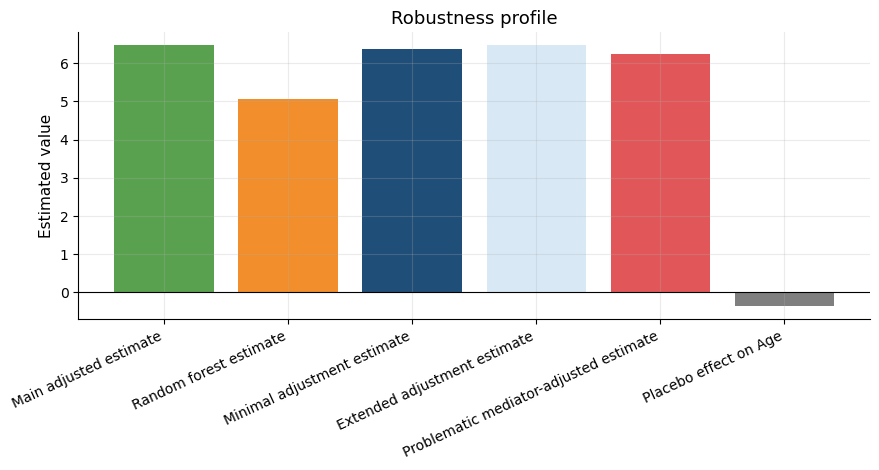

In [32]:
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_summary = robustness_summary.copy()
ax.bar(
    plot_summary["Check"],
    plot_summary["Value"],
    color=[COLORS["green"], COLORS["orange"], COLORS["navy"], COLORS["light_blue"], COLORS["red"], COLORS["gray"]]
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Robustness profile")
ax.set_ylabel("Estimated value")
plt.xticks(rotation=25, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()


#### Interpretation

The robustness profile supports a cautious positive conclusion.

The primary estimate, reasonable alternative adjustment sets, and the flexible model all estimate a positive treatment effect. The magnitude varies from about **5.055** to **6.467** among the main reasonable estimates.

The placebo check is close to zero, which does not suggest an obvious design failure.

Robustness checks do not make assumptions disappear. They show how much the conclusion depends on those assumptions.


</pr>

---
### 3.9 Step 9: report causal conclusions responsibly

A causal estimate should not be presented as a simple fact. It should be reported together with the question, estimand, adjustment strategy, assumptions, robustness checks, and limitations.


In [33]:
report_summary = pd.DataFrame({
    "Item": [
        "Causal question",
        "Estimand",
        "Main estimate",
        "Alternative model estimate",
        "Adjustment set",
        "Key assumption",
        "Overlap",
        "Placebo check",
        "Recommended claim strength",
    ],
    "Summary": [
        "Effect of assigning treatment on average recovery score",
        "Average Treatment Effect (ATE)",
        f"{adjusted_ate:.3f} recovery-score points",
        f"{rf_adjusted_ate:.3f} recovery-score points",
        ", ".join(candidate_adjustment_set),
        "No major unmeasured confounding after adjustment",
        "Partial but imperfect propensity-score overlap",
        f"Estimated effect of treatment on Age: {placebo_effect:.3f}",
        "Cautious causal estimate under stated assumptions",
    ]
})

display_df(report_summary)


,Item,Summary
0,Causal question,Effect of assigning treatment on average recov...
1,Estimand,Average Treatment Effect (ATE)
2,Main estimate,6.467 recovery-score points
3,Alternative model estimate,5.055 recovery-score points
4,Adjustment set,"Age, Socioeconomic, Severity, Biomarker, Hospi..."
5,Key assumption,No major unmeasured confounding after adjustment
6,Overlap,Partial but imperfect propensity-score overlap
7,Placebo check,Estimated effect of treatment on Age: -0.362
8,Recommended claim strength,Cautious causal estimate under stated assumptions


#### Example final interpretation

Under the candidate graph and assuming that `Age`, `Socioeconomic`, `Severity`, `Biomarker`, and `HospitalPolicy` are sufficient to adjust for treatment-selection bias, the adjusted linear analysis estimates that assigning treatment would increase the average recovery score by approximately **6.467 points**.

A flexible random forest outcome model gives a smaller but still positive estimate of approximately **5.055 points**. The result is also stable across reasonable adjustment sets: the minimal adjustment estimate is **6.361**, and adding `Access` gives **6.466**.

The placebo-style check estimates the effect of treatment on `Age` as **-0.362**, which is close to zero and does not suggest an obvious design failure.

Because the data are observational, this should be interpreted as a causal estimate under stated assumptions, not as experimental proof. The main remaining limitations are possible unmeasured confounding and imperfect overlap between treated and untreated patients.

> This interpretation is stronger than a purely associational statement, but still cautious. It avoids saying that the treatment is proven to work. Instead, it says that the treatment is estimated to improve recovery under the stated causal assumptions.

#### What should be reported?

| Reporting element | What to include |
|---|---|
| Causal question | What intervention or exposure is being studied? |
| Estimand | ATE, ATT, CATE, mediation effect, or another target |
| Unit and outcome | What is the unit of analysis and outcome variable? |
| Candidate graph | What assumptions define the causal structure? |
| Adjustment strategy | Which variables were adjusted for and why? |
| Variables avoided | Mediators, colliders, outcomes, or post-treatment variables |
| Estimation method | Regression adjustment, causal ML, propensity method, discovery method, etc. |
| Robustness checks | Alternative adjustment sets, model sensitivity, placebo checks, overlap |
| Limitations | Missing variables, measurement error, weak overlap, selection bias |
| Claim strength | Association, causal estimate under assumptions, or stronger evidence |

The practical rule is:

> Report causal results as structured arguments, not as isolated numbers.


</pr>

---
## 4. Reveal the hidden data-generating process

So far, we have acted like applied researchers working with an observational dataset. We did not assume that the true causal graph was known.

Because this is a simulated teaching example, we can now reveal the hidden data-generating process. This lets us compare our candidate graph and estimates with the true structure used to generate the data.

In real research, this reveal is not available. The purpose here is educational: to show what the workflow recovered well, what remained uncertain, and why assumptions still matter.


---
### 4.1 The hidden causal graph

The true simulation included one important variable that was not available to the analyst: `LatentFrailty`.

This variable represents unobserved patient frailty or underlying health status. It affects baseline clinical state and recovery, but it was not included in the observed dataset.


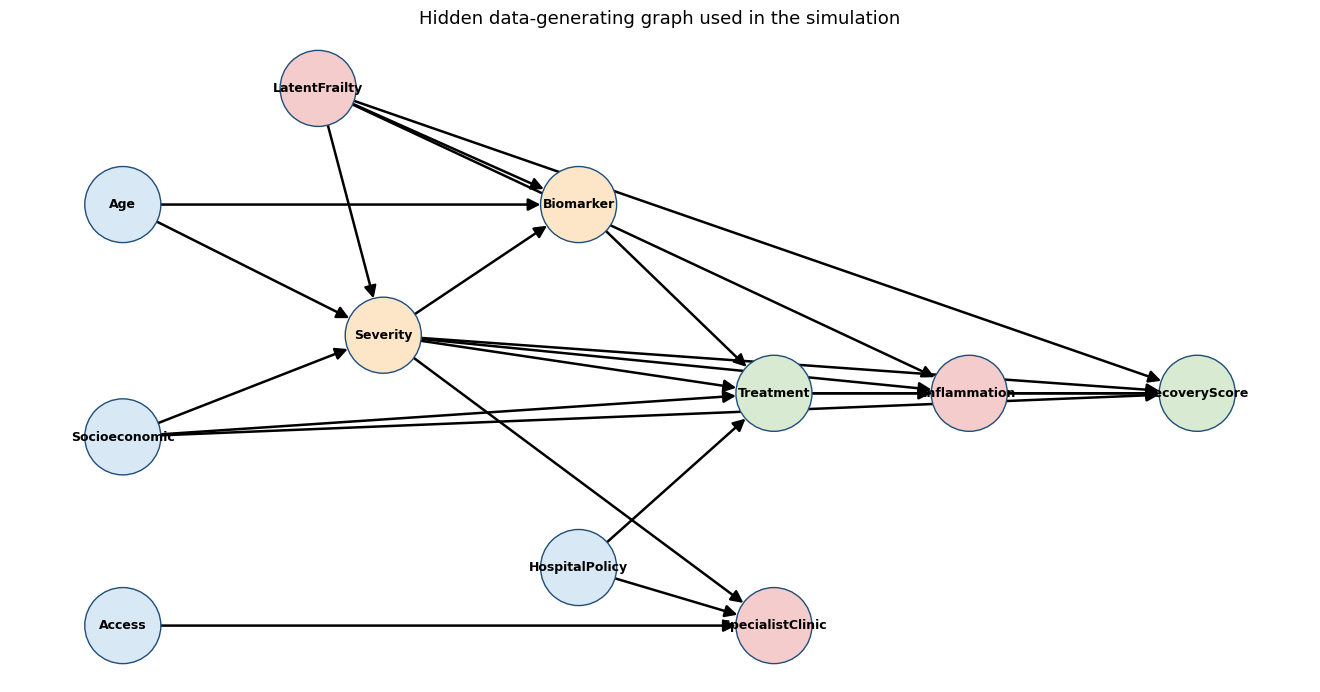

In [34]:
hidden_edges = [
    ("Age", "Severity"),
    ("Age", "Biomarker"),
    ("Socioeconomic", "Severity"),
    ("Socioeconomic", "Treatment"),
    ("Socioeconomic", "RecoveryScore"),
    ("LatentFrailty", "Severity"),
    ("LatentFrailty", "Biomarker"),
    ("LatentFrailty", "RecoveryScore"),
    ("Severity", "Biomarker"),
    ("Severity", "Treatment"),
    ("Severity", "RecoveryScore"),
    ("Biomarker", "Treatment"),
    ("HospitalPolicy", "Treatment"),
    ("Treatment", "RecoveryScore"),
    ("Treatment", "Inflammation"),
    ("Severity", "Inflammation"),
    ("LatentFrailty", "Inflammation"),
    ("Inflammation", "RecoveryScore"),
    ("Access", "SpecialistClinic"),
    ("Severity", "SpecialistClinic"),
    ("HospitalPolicy", "SpecialistClinic"),
]

hidden_pos = {
    "Age": (-3.2, 1.4),
    "Socioeconomic": (-3.2, -0.2),
    "Access": (-3.2, -1.5),
    "LatentFrailty": (-2.0, 2.2),
    "Severity": (-1.6, 0.5),
    "Biomarker": (-0.4, 1.4),
    "HospitalPolicy": (-0.4, -1.1),
    "Treatment": (0.8, 0.1),
    "Inflammation": (2.0, 0.1),
    "RecoveryScore": (3.4, 0.1),
    "SpecialistClinic": (0.8, -1.5),
}

hidden_node_colors = {
    "Age": COLORS["light_blue"],
    "Socioeconomic": COLORS["light_blue"],
    "Access": COLORS["light_blue"],
    "LatentFrailty": COLORS["light_red"],
    "Severity": COLORS["light_orange"],
    "Biomarker": COLORS["light_orange"],
    "HospitalPolicy": COLORS["light_blue"],
    "Treatment": COLORS["light_green"],
    "Inflammation": COLORS["light_red"],
    "RecoveryScore": COLORS["light_green"],
    "SpecialistClinic": COLORS["light_red"],
}

G_hidden = draw_dag(
    hidden_edges,
    pos=hidden_pos,
    title="Hidden data-generating graph used in the simulation",
    node_colors=hidden_node_colors,
    figsize=(13, 6.5)
)


#### Interpretation

The hidden graph shows that our candidate graph captured many important structures:

- `Severity` and `Biomarker` help explain treatment assignment;
- `Severity`, `Socioeconomic`, and `Treatment` affect `RecoveryScore`;
- `Inflammation` is post-treatment and lies on a pathway to recovery;
- `SpecialistClinic` is a selection variable influenced by multiple causes;
- `HospitalPolicy` affects treatment assignment.

However, the hidden graph also includes `LatentFrailty`, which was not observed. It affects `Severity`, `Biomarker`, `Inflammation`, and `RecoveryScore`.

This means the observed variables only partially capture baseline patient risk. Even a careful adjustment strategy can be biased if an important confounder is unmeasured.


---
### 4.2 Compare candidate graph with hidden graph

This comparison is possible only because the dataset is simulated. In real research, we would compare candidate graphs using domain knowledge, temporal logic, robustness checks, external validation, or interventional evidence.


In [35]:
candidate_edge_set = set(candidate_edges)
hidden_observed_edge_set = {edge for edge in hidden_edges if "LatentFrailty" not in edge}

correct_edges = candidate_edge_set.intersection(hidden_observed_edge_set)
missing_edges = hidden_observed_edge_set.difference(candidate_edge_set)
extra_edges = candidate_edge_set.difference(hidden_observed_edge_set)

graph_comparison = pd.DataFrame({
    "Comparison": [
        "Candidate edges also in hidden observed graph",
        "Hidden observed edges missed by candidate graph",
        "Candidate edges not in hidden observed graph",
    ],
    "Number of edges": [len(correct_edges), len(missing_edges), len(extra_edges)],
    "Edges": [sorted(correct_edges), sorted(missing_edges), sorted(extra_edges)],
})

display_df(graph_comparison)


,Comparison,Number of edges,Edges
0,Candidate edges also in hidden observed graph,16,"[(Access, SpecialistClinic), (Age, Biomarker),..."
1,Hidden observed edges missed by candidate graph,1,"[(HospitalPolicy, SpecialistClinic)]"
2,Candidate edges not in hidden observed graph,1,"[(Biomarker, RecoveryScore)]"


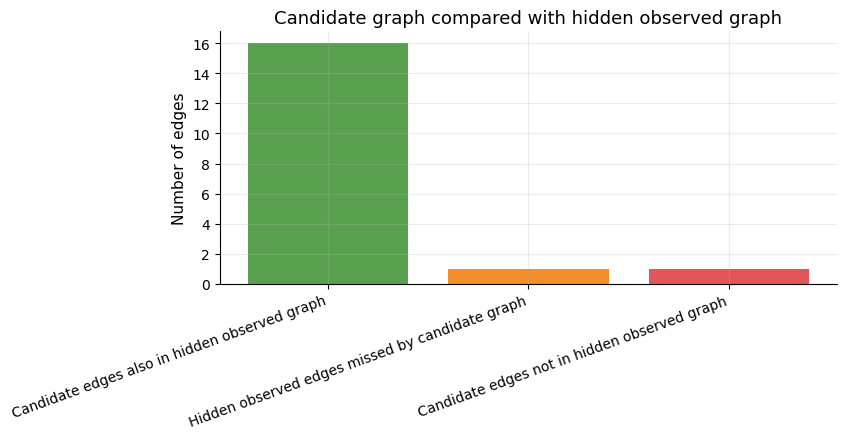

In [36]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
edge_counts = graph_comparison[["Comparison", "Number of edges"]]
ax.bar(edge_counts["Comparison"], edge_counts["Number of edges"], color=[COLORS["green"], COLORS["orange"], COLORS["red"]])
ax.set_title("Candidate graph compared with hidden observed graph")
ax.set_ylabel("Number of edges")
plt.xticks(rotation=20, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()


#### Interpretation

The candidate graph was close to the hidden observed graph: **16** edges were shared.

It missed one observed hidden edge: `HospitalPolicy → SpecialistClinic`. It also included one extra edge: `Biomarker → RecoveryScore`.

This is a good teaching result. The candidate graph was useful, but not perfect. In real research, a candidate graph is a working model, not the truth.


---
### 4.3 Compare estimated effects with the true effect

Because this is a simulation, we know both potential outcomes:

- `Y0`: recovery score under no treatment;
- `Y1`: recovery score under treatment.

Therefore, we can compute the true Average Treatment Effect:

$$ATE = E[Y(1) - Y(0)]$$

This is not possible in real observational data. We use it here only to evaluate the workflow.


In [37]:
true_ate = (hidden_truth["Y1"] - hidden_truth["Y0"]).mean()

truth_comparison = pd.DataFrame({
    "Quantity": [
        "Naive observed difference",
        "Adjusted linear estimate",
        "Adjusted random forest estimate",
        "True ATE from hidden potential outcomes",
    ],
    "Value": [
        naive_ate,
        adjusted_ate,
        rf_adjusted_ate,
        true_ate,
    ]
})

truth_comparison["Absolute error vs true ATE"] = (
    truth_comparison["Value"] - true_ate
).abs()

display_df(truth_comparison.round(3))


,Quantity,Value,Absolute error vs true ATE
0,Naive observed difference,-5.818,11.831
1,Adjusted linear estimate,6.467,0.454
2,Adjusted random forest estimate,5.055,0.957
3,True ATE from hidden potential outcomes,6.013,0.000


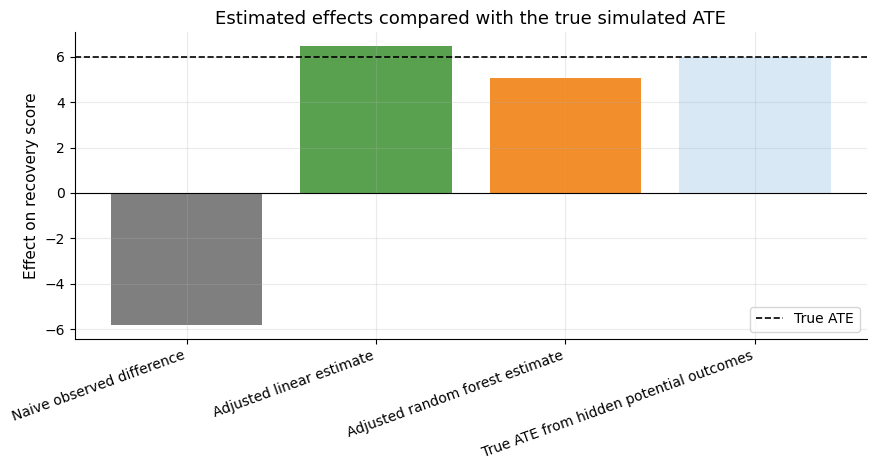

In [38]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(
    truth_comparison["Quantity"],
    truth_comparison["Value"],
    color=[COLORS["gray"], COLORS["green"], COLORS["orange"], COLORS["light_blue"]],
)
ax.axhline(true_ate, color="black", linewidth=1.2, linestyle="--", label="True ATE")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Estimated effects compared with the true simulated ATE")
ax.set_ylabel("Effect on recovery score")
ax.legend()
plt.xticks(rotation=20, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()


#### Interpretation

The hidden simulation reveals that the true ATE is **6.013** recovery-score points.

The naive observed difference was **-5.818**, with an absolute error of **11.831**. This is very misleading and has the wrong sign.

The adjusted linear estimate was **6.467**, with an absolute error of **0.454**. This is close to the true ATE.

The adjusted random forest estimate was **5.055**, with an absolute error of **0.957**. This is also much closer than the naive comparison, although it underestimates the true effect.

The teaching story is:

**naive comparison = -5.818 → adjusted estimate = 6.467 → true simulated ATE = 6.013**

A careful causal workflow can greatly improve an analysis, but it does not eliminate the need for assumptions.


---
### 4.4 What did the workflow teach us?

| Lesson | Meaning |
|---|---|
| Candidate graphs are useful | They make assumptions visible and guide adjustment choices |
| Causal discovery is limited | It can support graph refinement, but it cannot reveal hidden truth automatically |
| Adjustment helps | Adjusting for appropriate pre-treatment variables can reduce confounding bias |
| Assumptions remain central | Unmeasured variables can still affect the credibility of causal claims |

The main value of the workflow is not that it guarantees the correct answer. Its value is that it makes the reasoning process transparent.

A good causal analysis should make clear:

- what question is being asked;
- what assumptions are being made;
- what variables are adjusted for and why;
- what variables are avoided and why;
- how robust the conclusion is;
- what limitations remain.


</pr>

---
## 5. Chapter summary

- Real causal research often begins with incomplete domain knowledge, uncertain graphs, observational data, and imperfect measurements.
- A credible causal analysis starts with a clear causal question, not with an algorithm.
- Time ordering helps distinguish pre-treatment variables, treatment variables, post-treatment variables, outcomes, and selection variables.
- A variable audit helps decide which variables may be confounders, mediators, colliders, proxies, outcomes, or selection variables.
- Candidate graphs are not the truth. They are transparent statements of assumptions that can be discussed, revised, and stress-tested.
- Causal discovery can support graph refinement, but it should be interpreted as hypothesis generation, not automatic causal proof.
- Identification asks whether the causal effect can be estimated from the observed data under explicit assumptions.
- Overlap and covariate balance diagnostics help evaluate whether treated and untreated units are comparable enough for adjustment-based estimation.
- Estimation methods should follow from the causal question, graph, adjustment strategy, and assumptions.
- Robustness checks help show whether the conclusion is sensitive to adjustment-set choice, model choice, or suspicious placebo effects.
- Responsible causal reporting should state the estimand, adjustment strategy, assumptions, robustness checks, limitations, and strength of evidence.

> The hidden data-generating process shows the main lesson of the chapter: a careful causal workflow can move an analysis closer to the causal target, but it does not remove the need for assumptions.

> The main teaching story is that the raw observational comparison gives the wrong conclusion. The naive comparison suggests a negative treatment effect (**-5.818**), but after adjusting for pre-treatment confounding, the estimated effect becomes positive (**6.467**) and close to the true simulated ATE (**6.013**).

---

## 6. References and Further Reading

### Foundational references

Pearl, J. (2009). [*Causality: Models, Reasoning, and Inference*](https://www.cambridge.org/core/books/causality/B0046844FAE10CBF274D4ACBDAEB5F5B). Cambridge University Press.  
A foundational reference for causal graphs, interventions, structural causal models, and the do-operator.

Hernán, M. A., and Robins, J. M. (2020). [*Causal Inference: What If*](https://miguelhernan.org/whatifbook). Chapman & Hall/CRC.  
A highly recommended reference for causal questions, target trials, adjustment, observational studies, and responsible causal interpretation.

Peters, J., Janzing, D., and Schölkopf, B. (2017). [*Elements of Causal Inference: Foundations and Learning Algorithms*](https://mitpress.mit.edu/9780262037310/elements-of-causal-inference/). MIT Press.  
A rigorous reference for causal graphs, structural causal models, invariance, and causal discovery.

Cunningham, S. (2021). [*Causal Inference: The Mixtape*](https://mixtape.scunning.com/). Yale University Press.  
A practical reference for causal research design, observational data, treatment effects, and empirical causal analysis.

Huntington-Klein, N. (2021). [*The Effect: An Introduction to Research Design and Causality*](https://theeffectbook.net/). Chapman & Hall/CRC.  
An accessible and applied reference for causal questions, identification, research design, and interpretation.

### Adjustment, balance, and sensitivity diagnostics

Austin, P. C. (2009). [Balance diagnostics for comparing the distribution of baseline covariates between treatment groups in propensity-score matched samples](https://pubmed.ncbi.nlm.nih.gov/19757444/). *Statistics in Medicine*, 28(25), 3083–3107.  
Useful for understanding standardized mean differences, covariate balance, and propensity-score diagnostics.

Cinelli, C., and Hazlett, C. (2020). [Making sense of sensitivity: extending omitted variable bias](https://academic.oup.com/jrsssb/article-abstract/82/1/39/7056023). *Journal of the Royal Statistical Society: Series B*, 82(1), 39–67.  
Useful for thinking about unmeasured confounding and sensitivity analysis in observational causal studies.

### Recent and modern references

Feuerriegel, S., Frauen, D., Melnychuk, V., Schweisthal, J., Hess, K., Curth, A., Bauer, S., Kilbertus, N., Kohane, I. S., and van der Schaar, M. (2024). [Causal machine learning for predicting treatment outcomes](https://www.nature.com/articles/s41591-024-02902-1). *Nature Medicine*, 30, 958–968.  
Relevant for modern causal machine learning, treatment-effect estimation, and healthcare applications.

Wang, L., Huang, S., Wang, S., Liao, J., Li, T., and Liu, L. (2024). [A survey of causal discovery based on functional causal model](https://doi.org/10.1016/j.engappai.2024.108258). *Engineering Applications of Artificial Intelligence*, 133, 108258.  
Relevant for causal discovery methods and the use of functional assumptions to infer causal structure.

Brouillard, P., Squires, C., Wahl, J., Kording, K. P., Sachs, K., Drouin, A., and Sridhar, D. (2024). [The Landscape of Causal Discovery Data: Grounding Causal Discovery in Real-World Applications](https://arxiv.org/abs/2412.01953). arXiv preprint.  
Relevant for understanding the gap between causal discovery benchmarks and real-world scientific applications.

Carloni, G., et al. (2025). [The role of causality in explainable artificial intelligence](https://wires.onlinelibrary.wiley.com/doi/10.1002/widm.70015). *WIREs Data Mining and Knowledge Discovery*.  
Useful as a bridge to the next chapter on causal explainability, robust AI, and responsible AI systems.